In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro
import shutil

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import DEG

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

TISSUE = "Striatum"
ADATA_PATH = f"/home/gdallagl/myworkdir/data/XDP/NucSec/DEG/{TISSUE}/NucSeq_{TISSUE}_curated_labelels_for_deg.h5ad"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp"

N_PCS_TO_USE = 9  # CHANGE THIS BASED ON YOUR ELBOW PLOT

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "ct_for_deg" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["age_of_death", "sex", "pct_counts_mt", "frac_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "total_counts"

# # mitluple etst correction pvalue thr
# ALPHA_MULTIPLE_TEST = 0.05
# LOGFC_THR=0.1
# PVAL_THR=0.05

In [2]:
adata = sc.read_h5ad(ADATA_PATH, backed="r")
adata.obs#.columns

,background_fraction,cell_probability,cell_size,droplet_efficiency,barcode,bcl,rna_index,library,library__barcode,frac_mito,...,mqs_numerical,mqs,immediate.cause.of.death,infection_related_death,leiden_0.1_all_cells,leiden_0.5_all_cells,leiden_0.07_all_cells,leiden_1.0_all_cells,leiden_2.0_all_cells,ct_for_deg
library__barcode,,,,,,,,,,,,,,,,,,,,,
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGACGTTCATGTGGT-1,0.002532,0.999955,15523.367188,2.215328,CGGACGTTCATGTGGT-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGACGTT...,0.001974,...,5.0,A,Septicemia,Yes,0,0,0,0,0,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTAGGCCTCCGTTGTC-1,0.003941,0.999955,15618.492188,2.163925,GTAGGCCTCCGTTGTC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GTAGGCCT...,0.001627,...,5.0,A,Septicemia,Yes,0,0,0,0,0,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACTCTCTGTCG-1,0.009691,0.999955,14187.895508,2.199903,TCGGGACTCTCTGTCG-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__TCGGGACT...,0.000281,...,5.0,A,Acute Myocardial Infarction,No,0,0,0,1,1,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCACAAGAGGCT-1,0.004581,0.999955,13582.982422,2.010379,CGGGTCACAAGAGGCT-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__CGGGTCAC...,0.000040,...,4.5,AB,Pnuemonia,Yes,0,0,0,0,0,Astrocyte
A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGACATTGTAAACCTC-1,0.004263,0.999955,12883.346680,2.069477,GGACATTGTAAACCTC-1,A22KHKGLT3,pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4,A22KHKGLT3__pXDPsHSrPuiv1d240321rxn4__GGACATTG...,0.000412,...,5.0,A,Acute Myocardial Infarction,No,0,0,0,1,1,Astrocyte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CATGAAGCAGGTGCGA-1,0.436521,0.999990,5263.216797,0.668542,CATGAAGCAGGTGCGA-1,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__CATG...,0.000000,...,4.0,B,NaN,No,1,14,1,23,43,Oligodendrocyte
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__GTGTTACCAGGCTTCA-1,0.436829,0.999953,4984.368164,0.725044,GTGTTACCAGGCTTCA-1,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__GTGT...,0.000000,...,5.0,A,Myocardial Infarction,No,1,14,1,22,42,Oligodendrocyte
250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ATAGGCACACTAGTTA-1,0.444862,0.999996,4720.072754,0.779890,ATAGGCACACTAGTTA-1,250328_SL-EXE_0516_A22N2VFLT4,SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12,250328_SL-EXE_0516_A22N2VFLT4__SI-TT-H12__ATAG...,0.001505,...,5.0,A,Acute Respiratory Failure,No,1,13,1,25,32,Oligodendrocyte


In [3]:
def calculate_pca(adata, calculate_or_project, saving_folder, variance_threshold=None, N_PCS_TO_USE=None, df_stats=None, df_loadings=None):
    
    # Common steps
    print("Normalising")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    if calculate_or_project == "calculate":
        # Find highly variable genes on HEALTHY only
        print("HVG")
        sc.pp.highly_variable_genes(adata, n_top_genes=3000)
        hvg = adata.var_names[adata.var['highly_variable']].tolist()  # Get as ordered list
        adata = adata[:, hvg].copy() # Subset with 01 Index
    elif calculate_or_project == "project":
        hvg = df_loadings.index.tolist()
        # Subset and REORDER to match loadings
        adata = adata[:, hvg].copy() # Subset wiht gene names
        assert all(adata.var_names == df_loadings.index), "Gene order mismatch!"

    # Ectarct dense matrix
    X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X

    # Scale using healthy statistics
    print("Scaling")
    if calculate_or_project == "calculate":
        scaler = StandardScaler(with_mean=True, with_std=True)
        X_scaled = scaler.fit_transform(X)

        mean_train = scaler.mean_
        var_train = scaler.var_

        df_stats = pd.DataFrame({
            "mean_train": mean_train,
            "var_train": var_train
        }, index=adata.var_names)
        df_stats.to_csv(f"{saving_folder}/healthy_stats.csv")
        
    elif calculate_or_project == "project":
        df_stats = df_stats.reindex(adata.var_names) # FORCE SAME ORDER
        mean_train = df_stats["mean_train"].values
        var_train = df_stats["var_train"].values

        X_scaled = (X - mean_train) / np.sqrt(var_train)


    # PCA 
    MAX_PCS_TO_COMPUTE = 50
    if calculate_or_project == "calculate":
        print("PCA on Healthy")
        pca = PCA(n_components=MAX_PCS_TO_COMPUTE, random_state=42, svd_solver="full")
        pcs = pca.fit_transform(X_scaled)

        if variance_threshold is not None:
            cumvar = np.cumsum(pca.explained_variance_ratio_)
            N_PCS_TO_USE = int(np.searchsorted(cumvar, variance_threshold) + 1)
            N_PCS_TO_USE = min(N_PCS_TO_USE, MAX_PCS_TO_COMPUTE)  # ← clamp
            print(f"Auto-selected {N_PCS_TO_USE} PCs "
                f"({cumvar[N_PCS_TO_USE-1]*100:.1f}% variance explained)")
        elif N_PCS_TO_USE is None:
            # ELBOW LOGIC
            var_explained = pca.explained_variance_ratio_
            cumvar = np.cumsum(var_explained)

            # # Elbow = point of maximum curvature (second derivative)
            # deltas = np.diff(var_explained)        # first derivative
            # curvature = np.diff(deltas)            # second derivative
            # N_PCS_TO_USE = int(np.argmax(curvature) + 2)  # +2: argmax is 0-based on double-diff array

            # KNEE
            x = np.arange(len(var_explained))
            x_norm = x / x.max()
            y_norm = var_explained / var_explained.max()
            distances = np.abs(y_norm - (y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm))
            N_PCS_TO_USE = int(np.argmax(distances) + 1)

            print(f"Auto-selected {N_PCS_TO_USE} PCs via elbow "
                f"({cumvar[N_PCS_TO_USE-1]*100:.1f}% variance explained using {MAX_PCS_TO_COMPUTE})")

        # Save pcs
        df_healthy = pd.DataFrame(
            pcs[:, :N_PCS_TO_USE],
            columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
        )
        df_healthy.insert(0, 'barcode', adata.obs_names.values)
        df_healthy.to_csv(f"{saving_folder}/healthy_pcs.csv", index=False)

        # Extract loadings (genes × PCs)
        loadings = pca.components_.T  # Shape: (n_genes, n_components)
        # save loadings
        df_loadings = pd.DataFrame(
            loadings[:, :N_PCS_TO_USE],
            index= adata.var_names,
            columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
        )
        df_loadings.to_csv(f"{saving_folder}/gene_loadings.csv")

    elif calculate_or_project == "project":
        print("PCA on Diseased")
        loadings = df_loadings.values # Shape: (n_genes, n_components)
        pcs = X_scaled @ loadings  # apply ppject wiht laodings
        num_pcs = pcs.shape[1]
        # save pcs
        df_diseased = pd.DataFrame(
            pcs,
            columns=[f'PC_{i+1}' for i in range(num_pcs)]
        )
        df_diseased.insert(0, 'barcode', adata.obs_names.values)
        df_diseased.to_csv(f"{saving_folder}/diseased_pcs.csv", index=False)


    # # Plot PCs of a fingle sample
    # sample_id = adata.obs[SAMPLE_VARIABLE].unique()[0]
    # adata_s = adata[adata.obs[SAMPLE_VARIABLE] == sample_id].to_memory().copy()
    # adata_s.obs = adata_s.obs.drop(columns=[c for c in adata_s.obs.columns if "PC_" in c])
    # adata_s.obs = adata_s.obs.merge(
    #     df_healthy if calculate_or_project == "calculate" else df_diseased,
    #     left_index=True,
    #     right_on="barcode",
    #     how="left", 
    #     validate="one_to_one"
    # )
    # pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
    # if "spatial" in adata.obsm.keys():
    #     adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
    #     sc.pl.embedding(adata_s, basis="spatial", color=["ct_for_deg", "Group_name", *pcs])
    # del adata_s

    # SAVE PCS + DIAGBOSTICS
    if calculate_or_project == "calculate":

        # Elbow plot
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'o-')
        plt.axvline(x=N_PCS_TO_USE, color='red', linestyle='--', label=f'Selected: PC {N_PCS_TO_USE}')
        plt.xlabel('Principal Component')
        plt.ylabel('Variance Explained')
        plt.title('Scree Plot')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{saving_folder}/elbow_plot.png", dpi=150)
        plt.show()

        # Top geens for each PC
        def get_top_genes_per_pc(pca, gene_names, n_top=20, n_pcs=6):
            """
            Create a simple DataFrame showing top N genes for each PC
            
            Returns DataFrame with columns: PC_1, PC_1_loading, PC_2, PC_2_loading, etc.
            """
            loadings = pca.components_.T  # (n_genes, n_PCs)
            
            result = {}
            
            for i in range(min(n_pcs, loadings.shape[1])):
                pc_name = f'PC_{i+1}'
                
                # Get absolute loadings
                abs_loadings = np.abs(loadings[:, i])
                
                # Get top N indices
                top_indices = np.argsort(abs_loadings)[::-1][:n_top]
                
                # Get gene names and actual loadings (with sign)
                top_genes = gene_names[top_indices]
                top_loadings = loadings[top_indices, i]
                
                # Add to result dictionary
                result[pc_name] = top_genes
                result[f'{pc_name}_loading'] = top_loadings
            
            # Create DataFrame
            df = pd.DataFrame(result)
            
            return df

        N_TOP_GENES = 20
        df_top_genes = get_top_genes_per_pc(
            pca, 
            gene_names=adata.var_names.values,
            n_top=N_TOP_GENES,
            n_pcs=N_PCS_TO_USE
        )
        display(df_top_genes)
        df_top_genes.to_csv(f"{saving_folder}/{N_TOP_GENES}_top_genes_per_pc.csv")

    print("Done.")
    
    return {
        'pcs': pcs,
        'df_stats': df_stats, 
        'df_loadings': df_loadings,
        'df_pcs': df_healthy if calculate_or_project == "calculate" else df_diseased
    }




In [4]:
def run_nebula_with_PCs(
    adata,  
    ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
    CONTRAST_VARIABLE,CONTRAST_BASELINE, CONTRAST_STIM,
    SAMPLE_VARIABLE,LIBRARY_SIZE_COL,COVARIATES_FOR_DEG,
    N_PCS_TO_USE=None, variance_threshold=None, delete_tmp_files=True,
):
                        

    ###################
    # Calculate PCA for Healthy
    ###################

    print("Running PCA on Healthy...")

    adata_healthy = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].to_memory().copy()

    adata_healthy.X = adata_healthy.layers["counts"].copy()

    results_healthy = calculate_pca(
        adata=adata_healthy,
        calculate_or_project="calculate",
        variance_threshold=variance_threshold,
        N_PCS_TO_USE=N_PCS_TO_USE,
        saving_folder=SAVE_HEALTHY_PCA_RESULT, 
    )

    df_stats_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/healthy_stats.csv", index_col=0)
    df_loadings_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/gene_loadings.csv", index_col=0)


    ###################
    # Calculate PCA for Diseased
    ###################

    print("Running PCA on Diseased...")

    adata_diseased = adata[adata.obs[CONTRAST_VARIABLE] == CONTRAST_STIM].to_memory().copy()

    adata_diseased.X = adata_diseased.layers["counts"].copy()

    results = calculate_pca(
        adata=adata_diseased,
        calculate_or_project="project",
        saving_folder=SAVE_HEALTHY_PCA_RESULT, 
        df_loadings=df_loadings_healthy,
        df_stats=df_stats_healthy
    )

    ###################
    # Merge
    ###################

    # Merge with Healthy (alredy claculted --> SAME for all)    
    df_pcs_healthy = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/healthy_pcs.csv")
    df_pcs_diseased = pd.read_csv(f"{SAVE_HEALTHY_PCA_RESULT}/diseased_pcs.csv")

    df_all = pd.concat([df_pcs_healthy, df_pcs_diseased], axis=0)
    df_all.to_csv(f"{SAVE_HEALTHY_PCA_RESULT}/pcs_all.csv", index=False)

    ###################
    # Save h5ad with these PCs
    ###################

    print("Saving h5ad file...")

    pcs = [c for c in df_all.columns if c.startswith("PC_")]
    for pc in pcs:
        if pc in adata.obs.columns.tolist():
            adata.obs = adata.obs.drop(columns=[pc])
    if "barcode" in adata.obs.columns:
        adata.obs = adata.obs.drop(columns=["barcode"])
    adata.obs = adata.obs.merge(df_all, how="left", left_index=True, right_on="barcode", validate="one_to_one")
    adata.obs.index = adata.obs["barcode"]  # restore original index
    adata.obs = adata.obs.drop(columns=["barcode"])

    # Sanity checks before saving
    assert adata.obs.shape[0] == adata.X.shape[0], \
        f"obs rows ({adata.obs.shape[0]}) != X rows ({adata.X.shape[0]})"
    assert all(adata.obs_names == adata.obs_names), "Index mismatch after merge"
    assert adata.obs_names.is_unique, "Duplicate barcodes after merge"
    print(f"adata intact: {adata.shape[0]} cells, {adata.shape[1]} genes")

    covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs]
    mask = adata.obs[covs].isna().any(axis=1)
    print(f"ATTENTION: Dropping {mask.sum()} cells with NaN covariates: {adata.obs_names[mask].tolist()}")
    adata = adata[~mask].copy()

    ADATA_PATH_H5AD = f"{os.path.splitext(ADATA_PATH_QS)[0]}.h5ad"
    adata.write_h5ad(ADATA_PATH_H5AD)

    ###################
    # Create qs file
    ###################

    print("Saving qs file...")

    import tempfile
    tmp_dir = tempfile.mkdtemp(dir="/tmp")
    adata.X = adata.layers["counts"].copy() # ATTENTION
    print("\tSaving files for R coversion...")
    preprocessing.save_files_for_R_conversion(adata, tmp_dir)
    print("\tBuilding R obj...")
    preprocessing.build_qs_from_python_files(tmp_dir, saving_path=ADATA_PATH_QS, contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_BASELINE)

    ###################
    # Run Nebula
    ###################

    print("Running Nebula...")

    # Define PCs cov
    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = ADATA_PATH_QS,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 30, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 20, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv"
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    ###################
    # Delete tmp files
    ###################

    if delete_tmp_files:
        os.remove(ADATA_PATH_H5AD)
        os.remove(ADATA_PATH_QS)



# Run for all ct

Astrocyte
/home/gdallagl/myworkdir/data/XDP/NucSec/DEG/Striatum/Astrocyte/NucSeq_Striatum_curated_labelels_for_deg.qs
Running PCA on Healthy...
Normalising
HVG
Scaling
PCA on Healthy
Auto-selected 7 PCs via elbow (8.2% variance explained using 50)


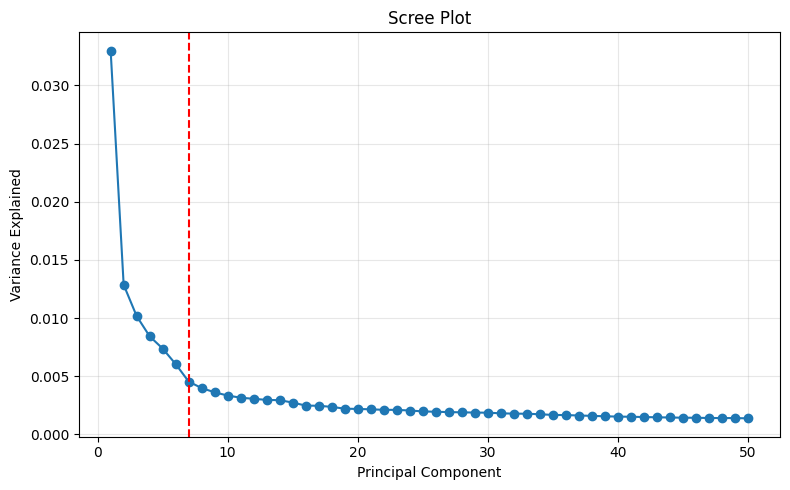

,PC_1,PC_1_loading,PC_2,PC_2_loading,PC_3,PC_3_loading,PC_4,PC_4_loading,PC_5,PC_5_loading,PC_6,PC_6_loading,PC_7,PC_7_loading
0,DCLK1,0.084127,HSPH1,0.096925,CLU,0.095100,PITPNC1,0.090881,DST,0.091863,F3,0.104610,LGR6,0.100478
1,SLC1A2,-0.080531,NR4A3,0.094553,NEAT1,0.090941,RPLP1,-0.089494,TPST1,0.084112,ACTN1,0.104588,SLC6A11,0.095313
2,CCDC85A,0.079941,MOBP,0.089334,MT2A,0.088877,GJA1,-0.089426,SERPINA3,0.082706,PLSCR1,0.100632,STK32A,0.088293
3,LINC01088,0.078084,FOSB,0.088613,MOBP,-0.088855,MT1F,-0.086042,OSMR,0.082688,GALNT16,0.095918,SHISA6,0.085276
4,C8orf34,0.074660,ZNF536,0.087965,ZNF536,-0.087166,MT3,-0.085278,GFAP,0.077390,SERPINA3,0.089524,HSP90AA1,0.083544
5,ROBO2,0.073008,BCAS1,0.087300,CRYAB,0.086970,RANBP3L,-0.082613,ITPKC,0.070601,TPST1,0.087994,HTR2C,0.081197
6,ADAMTSL3,0.071808,ST18,0.086730,ST18,-0.086917,TALAM1,-0.081205,ARHGEF3,0.070334,OSMR,0.087088,PDK4,0.080148
7,RTN1,0.071475,LINC02882,0.085775,BCAS1,-0.085468,ATP5F1E,-0.081119,DNAH11,-0.069510,UBASH3B,0.086404,TTC6,0.079282
8,SLC38A1,0.071077,ANO4,0.085147,PFKP,0.085028,MT1G,-0.080733,WIF1,-0.068080,ARHGEF3,0.085270,DTHD1,0.078463
9,CD44,0.071045,HSPD1,0.084061,SLC24A2,-0.084756,RPL30,-0.079143,CFAP299,-0.068003,C11orf96,0.082382,C7orf78,0.076380


Done.
Running PCA on Diseased...
Normalising
Scaling
PCA on Diseased
Done.
Saving h5ad file...
adata intact: 29405 cells, 38601 genes
ATTENTION: Dropping 1 cells with NaN covariates: ['A22KHKGLT3__pXDPsHSrCaiv1d240321rxn4__AAGGAGCTCTGAGGGA-1']
Saving qs file...
	Saving files for R coversion...
	Building R obj...


2026-02-21 03:43:17 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-02-21 03:43:17 | [WARNING] R callback write-console: Loading required package: sp
  
2026-02-21 03:43:18 | [WARNING] R callback write-console: 
Attaching package: ‘SeuratObject’

  
2026-02-21 03:43:18 | [WARNING] R callback write-console: The following objects are masked from ‘package:base’:

    %||%, intersect, t

  



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

2026-02-21 03:43:21 | [WARNING] R callback write-console: 
Attaching package: ‘Seurat’

  
2026-02-21 03:43:21 | [WARNING] R callback write-console: The following object is masked from ‘package:base’:

    %||%

  
2026-02-21 03:43:21 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  



Setting condition reference level to: Control
Levels: Control XDP 
[1] "Creating Seurat object..."


2026-02-21 03:44:16 | [WARNING] R callback write-console: Warning:  
2026-02-21 03:44:16 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
Running Nebula...
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/data/XDP/NucSec/DEG/Striatum/Astrocyte/NucSeq_Striatum_curated_labelels_for_deg.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '30', '--n-cores', '20', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/data/XDP/NucSec/DEG/Striatum/Astrocyte/NucSeq_Striatum_curated_labelels_for_deg.qs --id-col donor_id --offset-col total_counts --n-folds 30 --n-cores 20 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/data/XDP/NucSec/DEG/Striatum/Astrocyte/NucSeq_Striatum_curated_labelels_for_deg.qs --id-col donor_id --offset-col total_counts --n-folds 30 --n-cores 20 --save-tmp 0 --covs condition,age_of_death,

In [6]:
for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist():

    #ct="eMSN_NUDAP"

    if "-" in ct:
        continue
    print(ct)

    # Select single ct
    adata_ct = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].to_memory().copy()

    # Define saving apthjs
    ADATA_PATH_QS = f"{os.path.dirname(ADATA_PATH)}/{ct}/{os.path.splitext(os.path.basename(ADATA_PATH))[0]}.qs"
    SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
    os.makedirs(SAVE_HEALTHY_PCA_RESULT, exist_ok=True)
    print(ADATA_PATH_QS)

    # Run enire pipeline for this ct
    run_nebula_with_PCs(
        adata_ct, 
        ADATA_PATH_QS, SAVE_HEALTHY_PCA_RESULT, PARALLEL_NEBULA_SCRIPT_PATH,
        CONTRAST_VARIABLE,CONTRAST_BASELINE, CONTRAST_STIM,
        SAMPLE_VARIABLE,LIBRARY_SIZE_COL,COVARIATES_FOR_DEG,
        N_PCS_TO_USE=None, variance_threshold=None,delete_tmp_files=True
    )

    shutil.rmtree(f"{SAVE_HEALTHY_PCA_RESULT}/de_results")
    #break

# Plot Results

In [4]:
df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")
df_grad

,gene,mean_spearman,combined_p
0,A1BG,-0.002360,5.349057e-07
1,A1BG-AS1,-0.007881,3.198023e-08
2,A1CF,0.007398,2.969691e-02
3,A2M,-0.002144,8.049117e-15
4,A2M-AS1,-0.000389,7.443913e-03
...,...,...,...
51538,ENSG00000277836,NaN,NaN
51539,ENSG00000278633,NaN,NaN
51540,ENSG00000276017,-0.008289,2.949804e-01
51541,ENSG00000278817,-0.027789,4.458387e-04


In [10]:
from gseapy import dotplot

ax = dotplot(
    df_top,
    column="neg_log10_fdr",      # color mapping
    x="NES",                      # x-axis
    y="Term",                     # y-axis  
    size=5,                       # dot size (fixed) or column name for variable size
    cmap="Reds",
    figsize=(8, max(4, len(df_top) * 0.4)),
    title=f"{ct} — GSEA (FDR ≤ 0.25, n={len(df_top)})",
    cutoff=0.25,
    top_term=len(df_top),         # show all pre-filtered terms
    show_ring=False,
)

# set vmin/vmax AFTER plotting by grabbing the scatter collection
sc = ax.collections[0]
sc.set_clim(vmin=1.3, vmax=df_top["neg_log10_fdr"].max())  # 1.3 = FDR 0.05

# update colorbar
ax.figure.axes[-1].set_ylabel("-log10(FDR q-val)")
ax.axvline(0, color="grey", lw=0.8, linestyle="--")
plt.tight_layout()
plt.show()

ValueError: Warning: No enrich terms when cutoff = 0.25

Astrocyte


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,ENSG00000272512,-0.902239,0.013550,False,-0.053565
1,ISG15,-0.565080,0.031263,False,-0.015398
2,MEGF6,0.820718,0.011293,False,-0.015189
3,ENSG00000289893,0.819551,0.000064,False,0.023600
4,ENSG00000288927,0.750455,0.021607,False,0.014151
...,...,...,...,...,...
342,BGN,0.767755,0.004334,False,-0.002935
343,ATP2B3,0.731428,0.017298,False,-0.017610
344,DUSP9,0.617629,0.008632,False,0.023113
345,GAB3,0.962773,0.000045,False,-0.005171


16


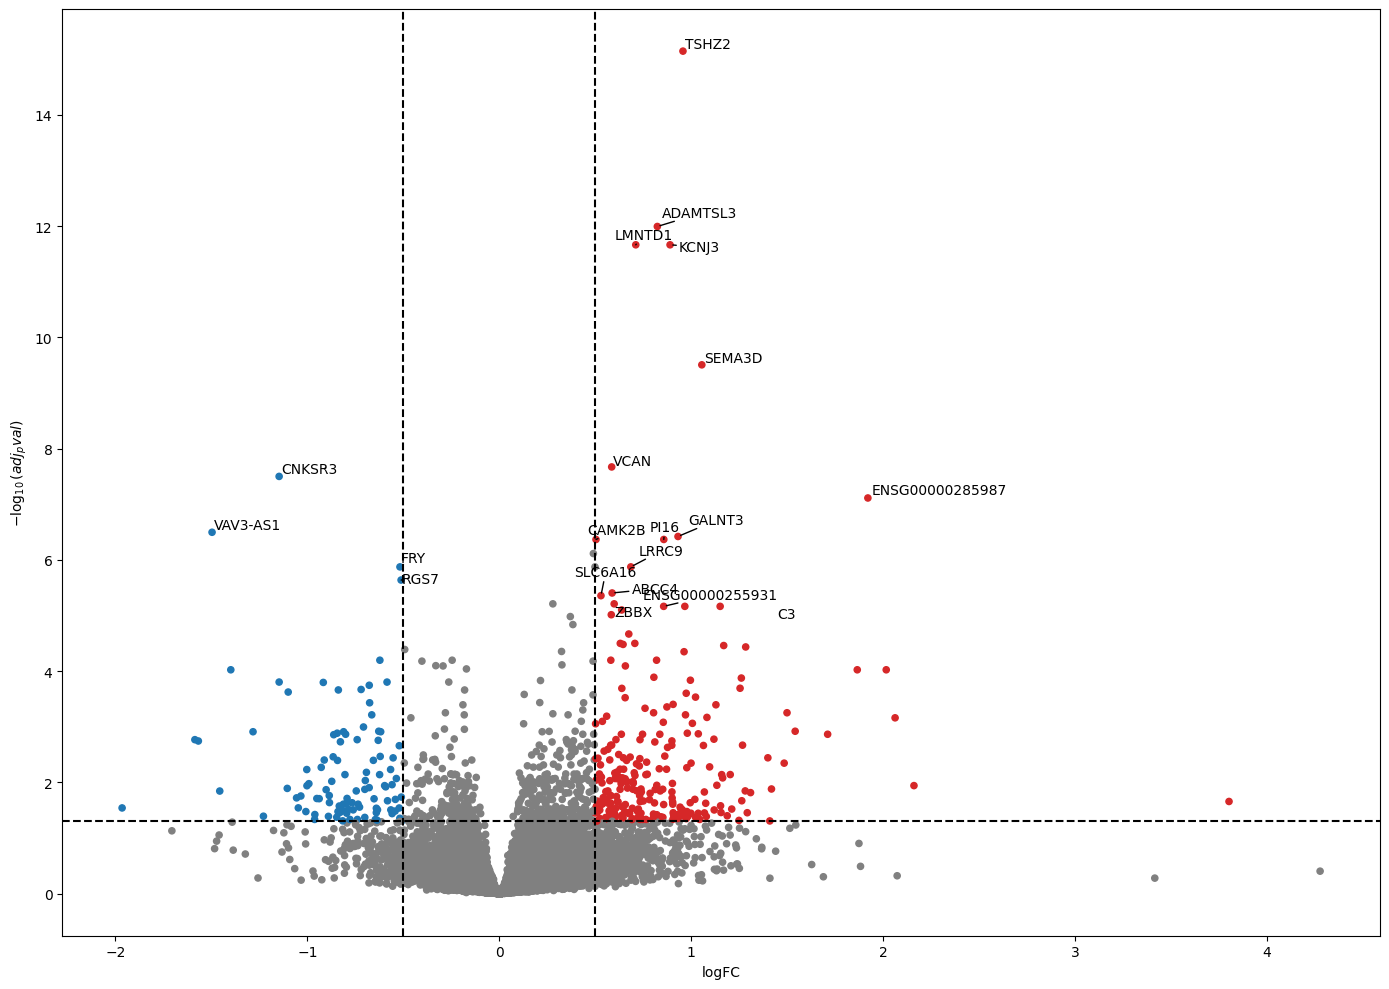

2026-02-21 14:50:11,352 [INFO] Parsing data files for GSEA.............................
2026-02-21 14:50:11,387 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:50:11,389 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 14:50:11,664 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:50:11,833 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:50:11,836 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:50:11,847 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:50:12,407 [INFO] 6068 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 14:50:12,409 [INFO] 7192 gene_sets used for further statistical testing.....
2026-02-21 14:50:12,410 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 14:54:01,938 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 2


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
1,Reactome_Pathways_2024__Peptide Ligand-Binding...,0.667711,2.011123,0.0,0.026568,24/61
0,DisGeNET__Sleeplessness,-0.693679,-2.097815,0.0,0.082450,11/30


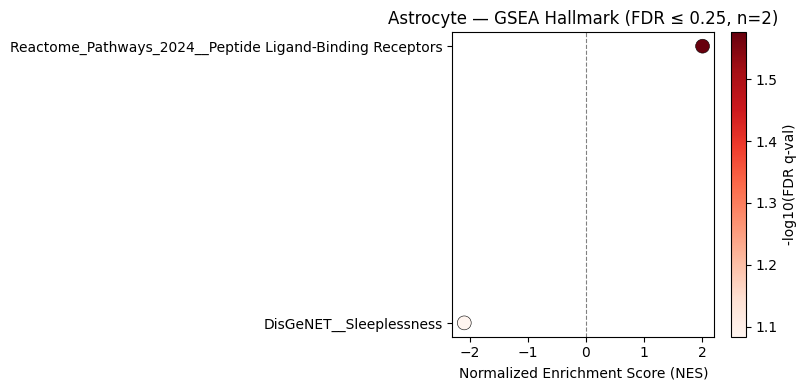

Ependymal


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,ACKR3,0.946547,0.006783,False,-0.083004
1,BCL6,0.553651,0.020710,False,0.043356
2,ENSG00000291090,1.510271,0.024137,False,NaN
3,ZNF587,-0.628305,0.028051,False,-0.019193
4,RUNX1,-0.875910,0.020710,False,-0.022311


0


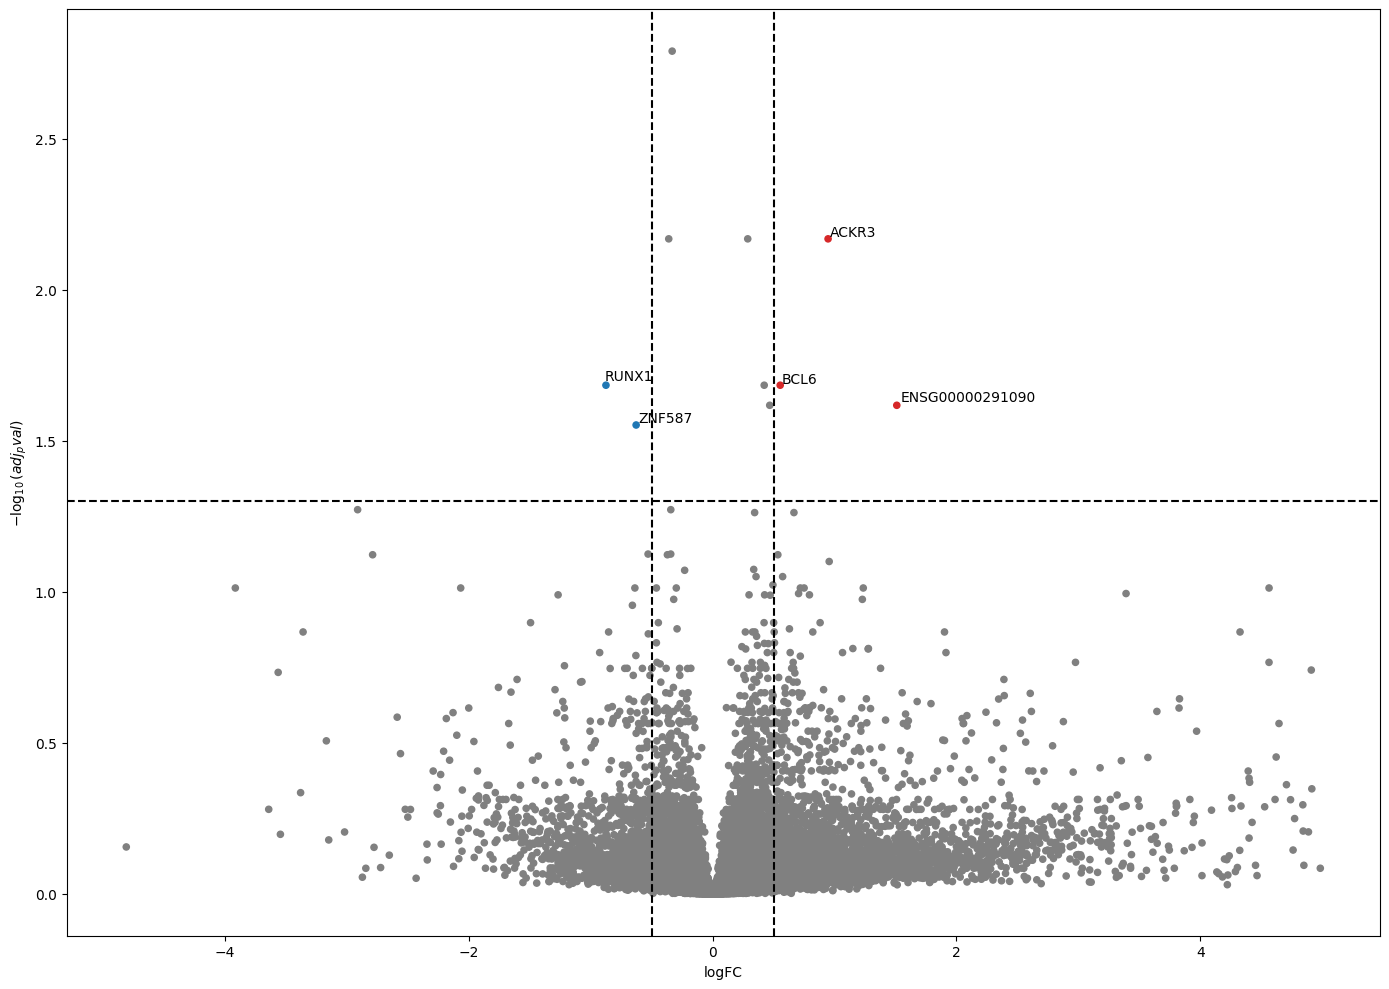

2026-02-21 14:54:05,313 [INFO] Parsing data files for GSEA.............................
2026-02-21 14:54:05,348 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:54:05,350 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 14:54:05,637 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:54:05,798 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:54:05,801 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:54:05,810 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:54:06,344 [INFO] 5961 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 14:54:06,346 [INFO] 7299 gene_sets used for further statistical testing.....
2026-02-21 14:54:06,346 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 14:57:59,201 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 50


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
15,Reactome_Pathways_2024__BBSome-mediated Cargo-...,0.740734,1.884226,0.000000,0.117347,6/21
13,Reactome_Pathways_2024__Aerobic Respiration an...,0.489492,1.887958,0.000000,0.128592,92/246
8,MSigDB_Hallmark_2020__Oxidative Phosphorylation,0.511183,1.917755,0.000000,0.138432,75/199
12,Reactome_Pathways_2024__Peptide Chain Elongation,0.554256,1.889784,0.001340,0.150036,46/87
10,Reactome_Pathways_2024__Viral mRNA Translation,0.559692,1.901992,0.000000,0.152682,37/87
4,MSigDB_Hallmark_2020__Androgen Response,0.561003,1.927932,0.000000,0.160825,38/92
20,GO_Cellular_Component_2025__Autophagosome Memb...,0.634507,1.852883,0.000000,0.163992,15/33
21,DisGeNET__Myoclonic dystonia,0.807507,1.845602,0.000000,0.172124,6/13
18,Reactome_Pathways_2024__Eukaryotic Translation...,0.541401,1.856655,0.001330,0.173294,38/90
22,Reactome_Pathways_2024__Formation of a Pool of...,0.529740,1.839213,0.001330,0.173503,40/99


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


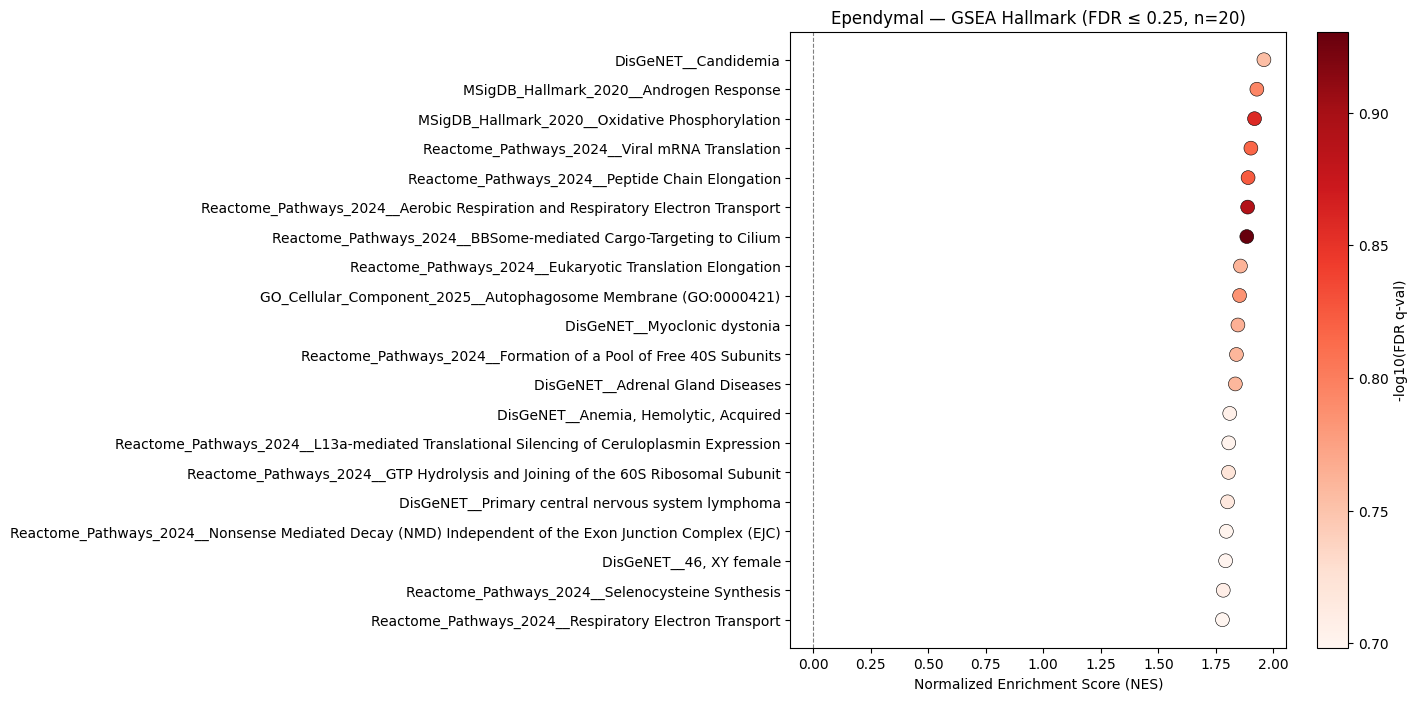

Vascular


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,FKBP5,0.835951,0.043693,False,0.025863
1,NR6A1,-1.036379,0.022734,False,-0.038175
2,IFITM2,0.690233,0.043693,False,-0.003070
3,ZBTB16,0.636626,0.020089,False,0.037332
4,ENSG00000267653,1.490595,0.022734,False,0.003116
5,SLC5A3,-0.810513,0.020089,False,0.097167


0


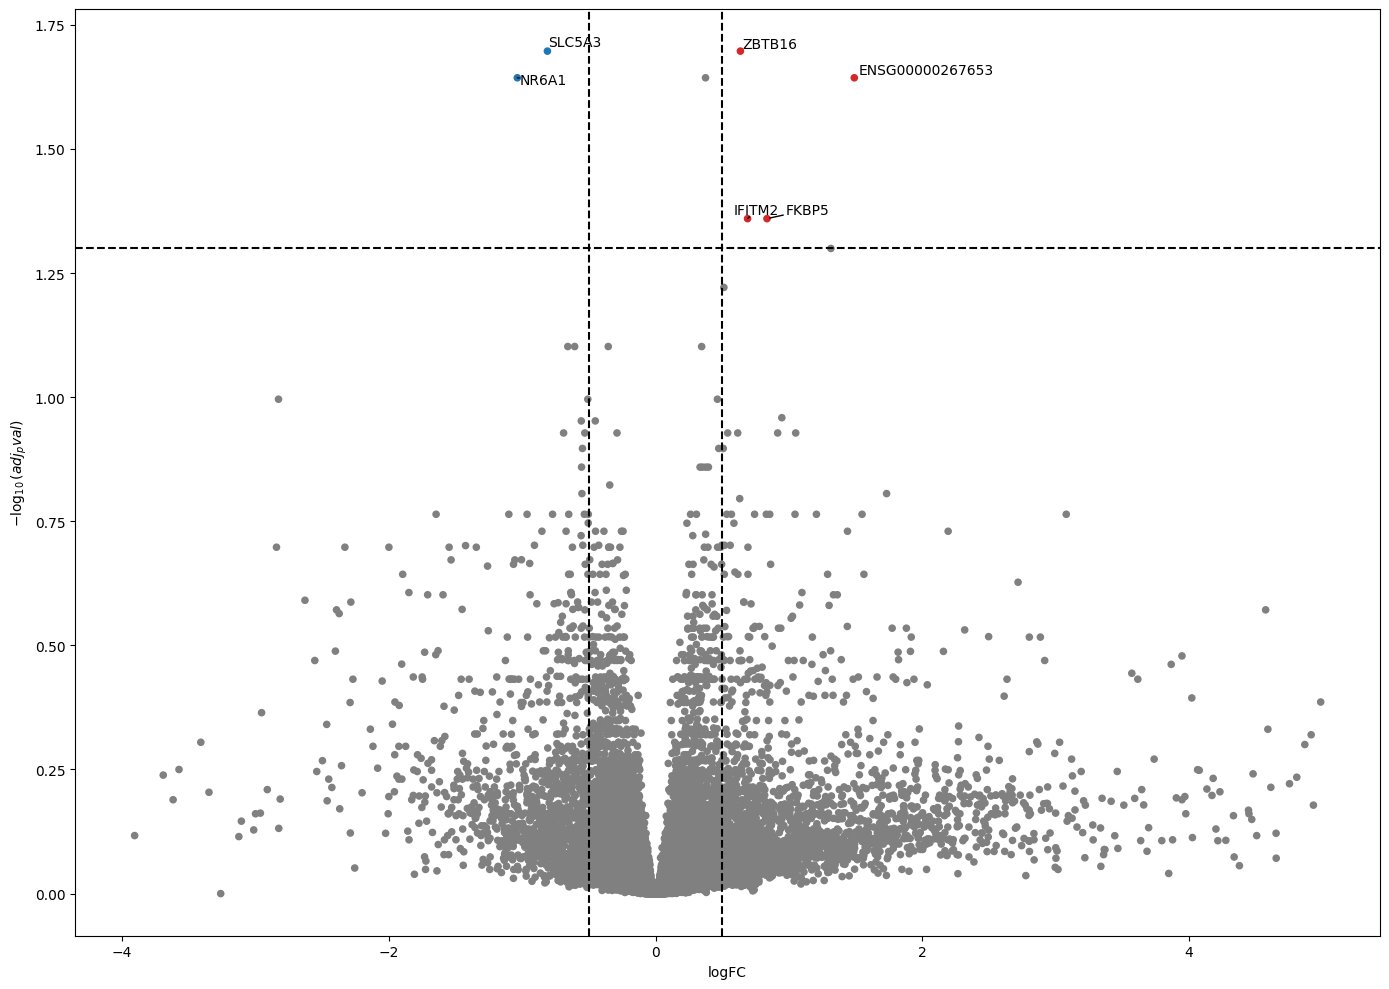

2026-02-21 14:58:02,786 [INFO] Parsing data files for GSEA.............................
2026-02-21 14:58:02,816 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:58:02,819 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 14:58:03,091 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:58:03,267 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:58:03,269 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:58:03,280 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 14:58:03,791 [INFO] 5897 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 14:58:03,793 [INFO] 7363 gene_sets used for further statistical testing.....
2026-02-21 14:58:03,794 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:01:31,600 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 123


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
0,Reactome_Pathways_2024__Formation of a Pool of...,0.753034,2.818891,0.0,0.0,69/99
1,Reactome_Pathways_2024__Selenoamino Acid Metab...,0.739510,2.816786,0.0,0.0,75/114
2,Reactome_Pathways_2024__GTP Hydrolysis and Joi...,0.739917,2.803173,0.0,0.0,73/110
18,Reactome_Pathways_2024__Nonsense-Mediated Deca...,0.689729,2.621952,0.0,0.0,70/113
19,Reactome_Pathways_2024__Nonsense Mediated Deca...,0.689729,2.621952,0.0,0.0,70/113
32,Reactome_Pathways_2024__SARS-CoV-1 Modulates H...,0.757941,2.333451,0.0,0.0,28/36
33,GO_Cellular_Component_2025__Cytosolic Small Ri...,0.739569,2.315573,0.0,0.0,28/39
29,Reactome_Pathways_2024__Major Pathway of rRNA ...,0.587017,2.358727,0.0,0.0,69/177
37,Reactome_Pathways_2024__Metabolism of Amino Ac...,0.534361,2.269759,0.0,0.0,102/294
26,Reactome_Pathways_2024__Translation Initiation...,0.705126,2.387095,0.0,0.0,34/58


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


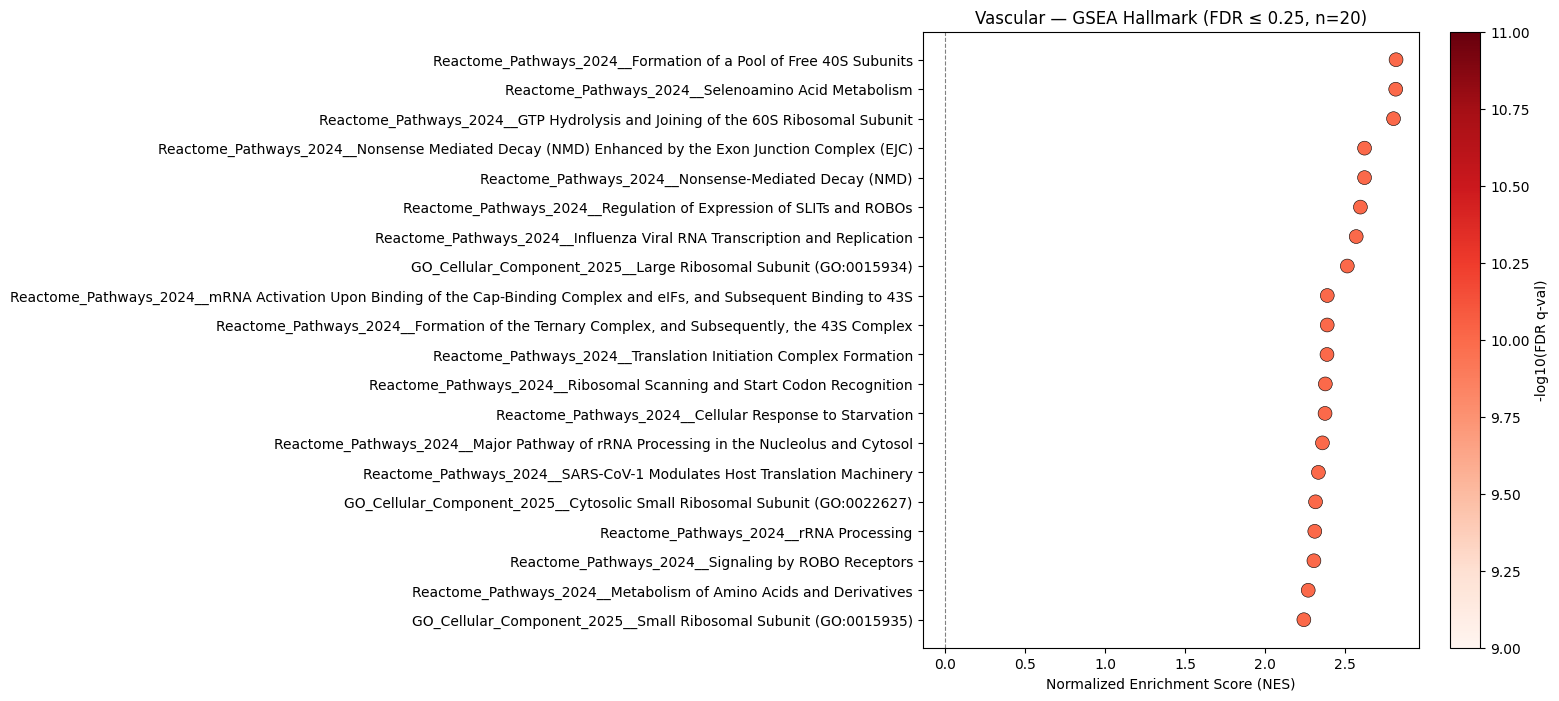

Microglia


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,AGTRAP,0.518321,0.028758,False,-0.015717
1,C1QA,0.532767,0.014981,False,0.000991
2,C1QC,0.564294,0.033111,False,-0.005536
3,IFNLR1,1.023987,0.002016,False,-0.000260
4,LOC105376892,0.764503,0.014981,False,NaN
...,...,...,...,...,...
68,RCAN1,0.558338,0.038335,False,-0.057330
69,CHCHD10,0.564908,0.002898,False,-0.004056
70,ENSG00000213279,1.048101,0.037472,False,-0.009695
71,VSIG4,0.711253,0.026044,False,0.002011


2


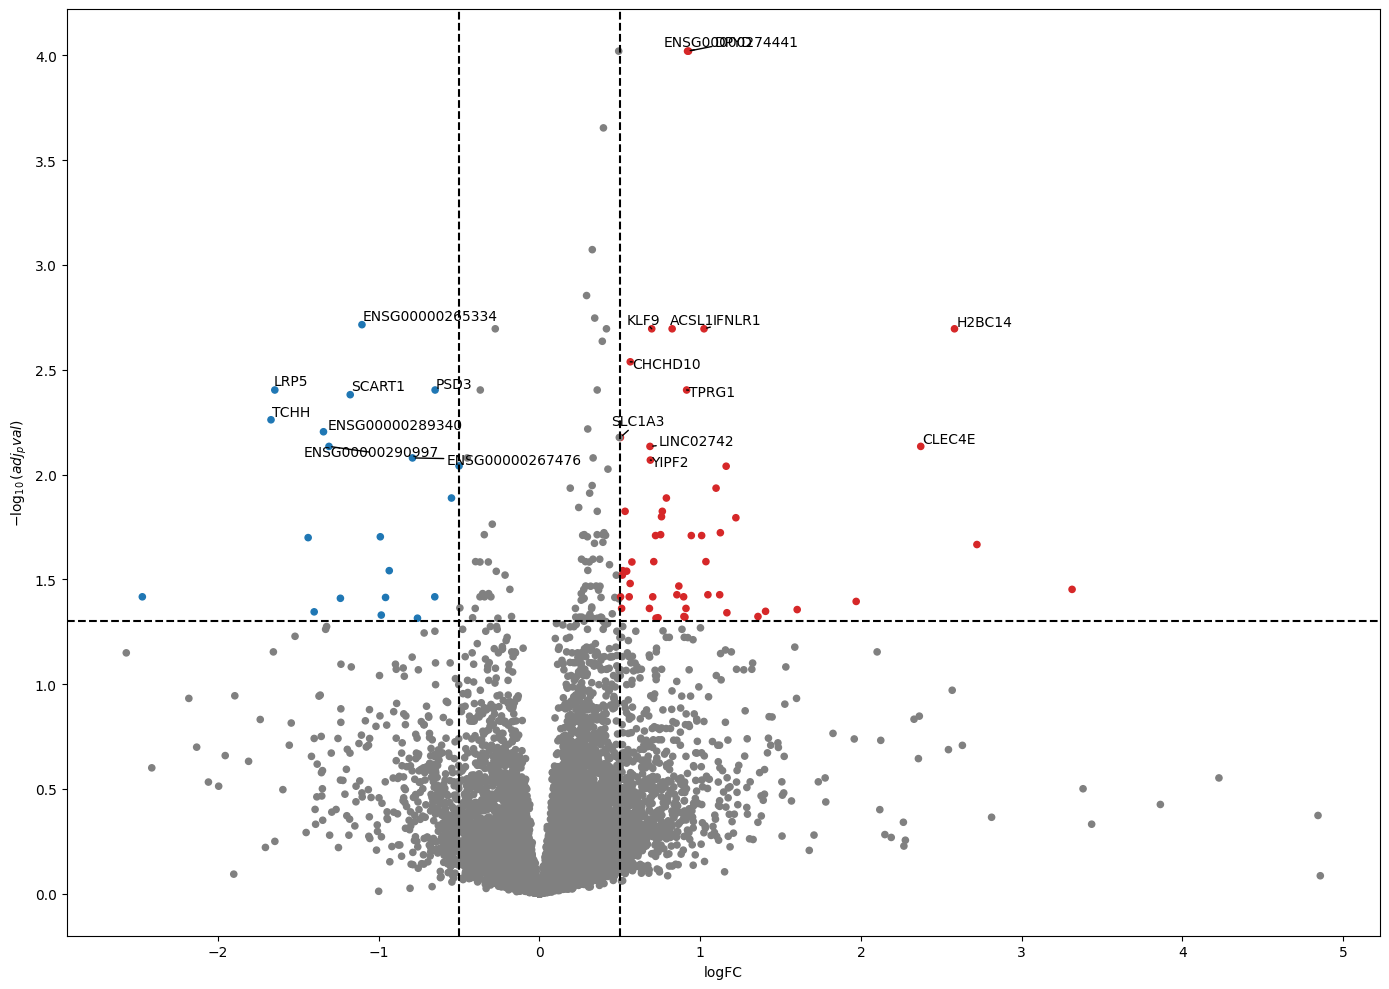

2026-02-21 15:01:36,409 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:01:36,434 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:01:36,436 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:01:36,708 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:01:36,873 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:01:36,876 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:01:36,885 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:01:38,976 [INFO] 6671 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:01:38,977 [INFO] 6589 gene_sets used for further statistical testing.....
2026-02-21 15:01:38,978 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:04:15,943 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 149


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
3,Reactome_Pathways_2024__Eukaryotic Translation...,0.643993,2.096307,0.0,0.000445,38/90
6,Reactome_Pathways_2024__Response of EIF2AK4 (G...,0.628825,2.074854,0.0,0.000445,41/99
5,Reactome_Pathways_2024__Eukaryotic Translation...,0.636678,2.082571,0.0,0.000593,39/90
2,Reactome_Pathways_2024__Peptide Chain Elongation,0.646685,2.108997,0.0,0.000889,39/87
12,Reactome_Pathways_2024__Formation of a Pool of...,0.618573,2.048839,0.0,0.001111,38/99
14,Reactome_Pathways_2024__Nonsense Mediated Deca...,0.622350,2.038551,0.0,0.001186,38/93
20,Reactome_Pathways_2024__Influenza Viral RNA Tr...,0.589855,2.016477,0.0,0.001207,41/133
16,Reactome_Pathways_2024__Selenoamino Acid Metab...,0.603286,2.030642,0.0,0.001212,38/110
19,Reactome_Pathways_2024__L13a-mediated Translat...,0.603725,2.020955,0.0,0.001231,40/109
8,Reactome_Pathways_2024__Viral mRNA Translation,0.632455,2.057085,0.0,0.001245,37/87


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


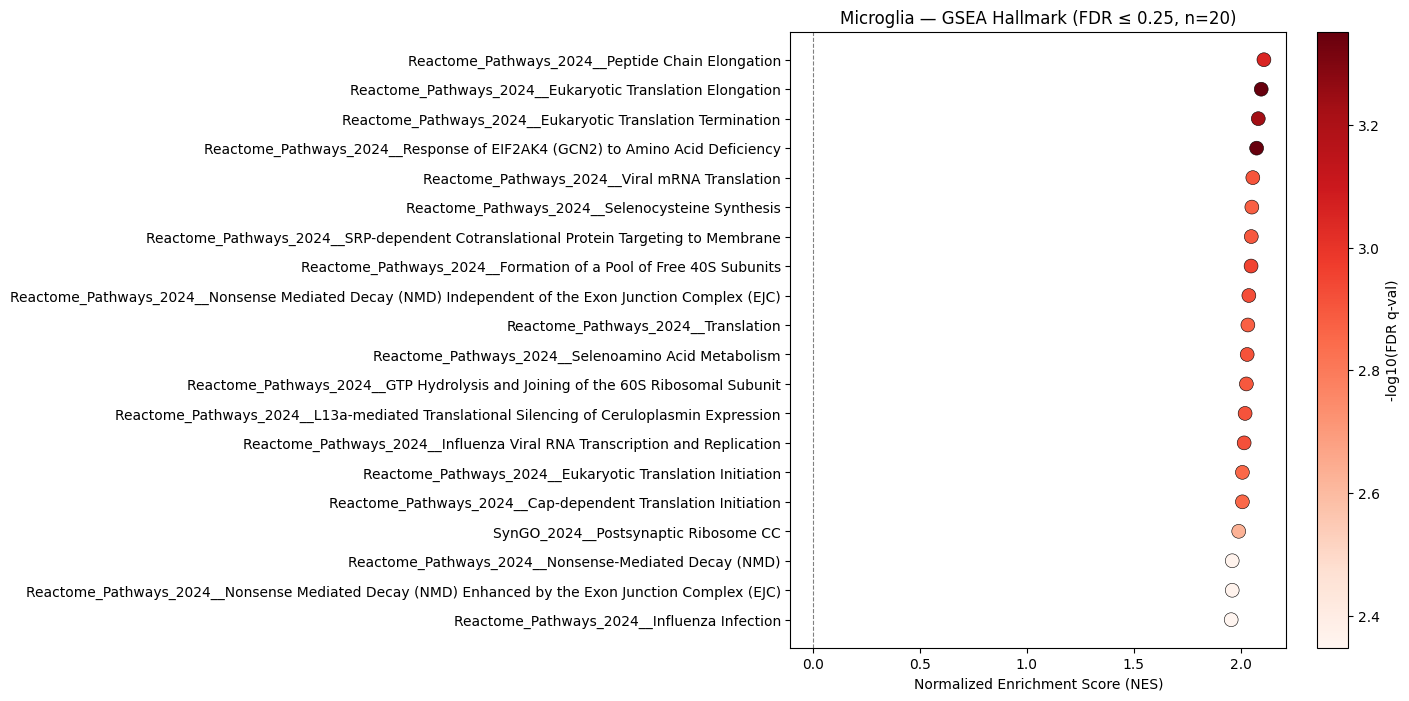

Neuron_non_MSN


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,LOC100288175,0.692312,0.017914,False,NaN
1,LINC01562,0.501054,0.002278,False,0.002238
2,ENSG00000285079,2.155435,0.018631,False,-0.011634
3,RGS4,-0.613487,0.016643,False,-0.173305
4,ENSG00000260077,0.900094,0.001980,False,-0.001729
...,...,...,...,...,...
61,ENSG00000287271,0.557172,0.043305,False,-0.023218
62,CEACAM1,0.747285,0.036619,False,0.000488
63,ENSG00000234083,1.396959,0.047049,False,-0.017186
64,LOC107985535,-0.999822,0.045278,False,NaN


0


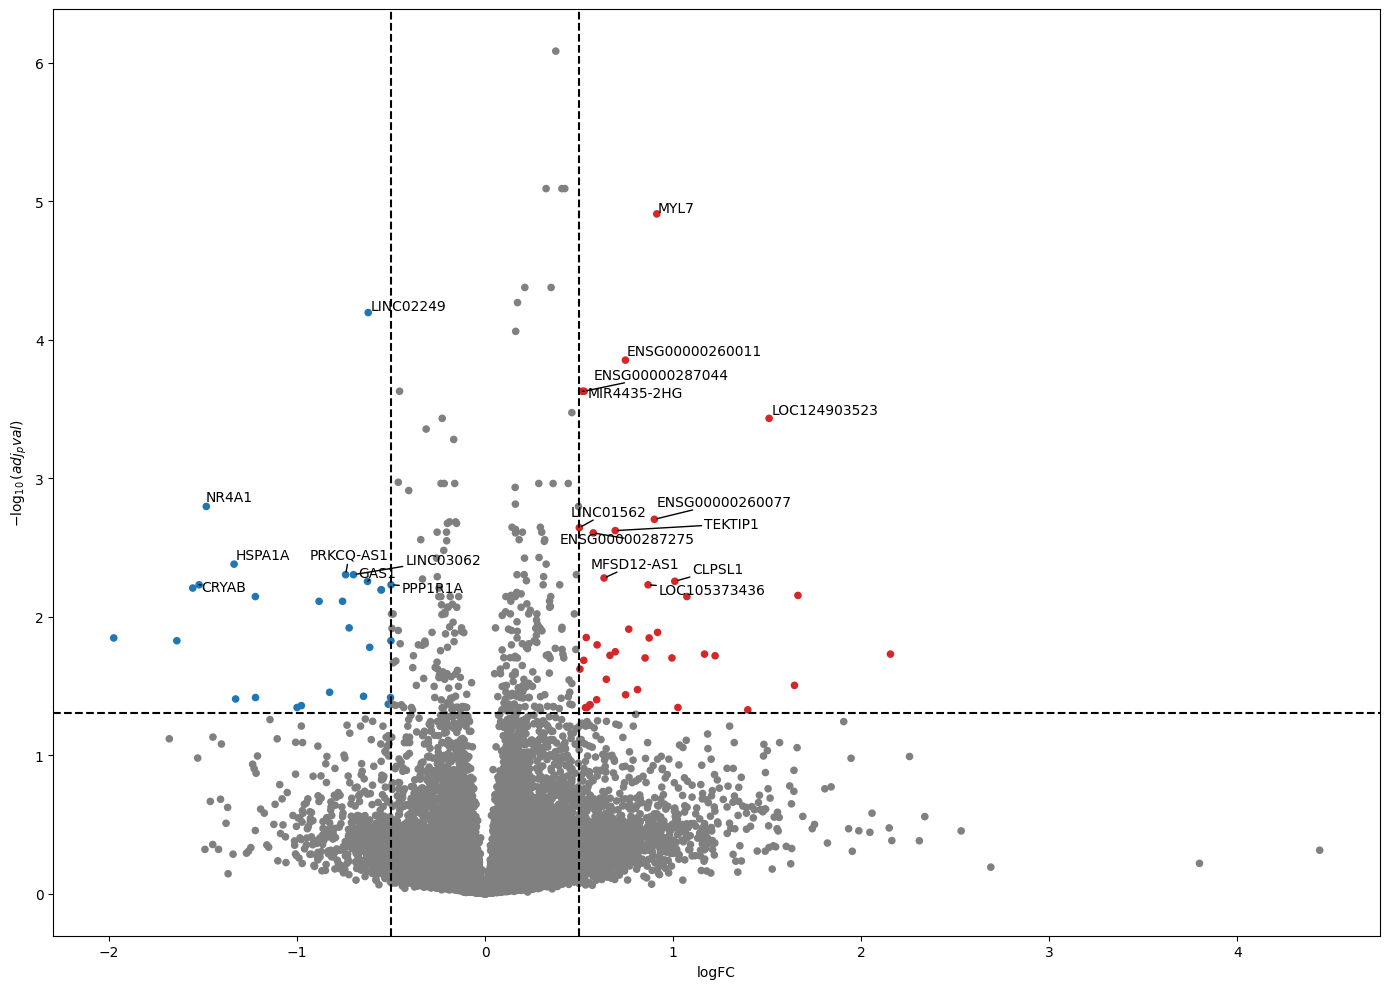

2026-02-21 15:04:19,910 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:04:19,957 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:04:19,960 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:04:20,241 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:04:20,419 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:04:20,421 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:04:20,431 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:04:20,984 [INFO] 5479 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:04:20,986 [INFO] 7781 gene_sets used for further statistical testing.....
2026-02-21 15:04:20,987 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:09:21,742 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 441


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
0,MSigDB_Hallmark_2020__TNF-alpha Signaling via ...,-0.575412,-2.396000,0.0,0.000000,72/171
4,GO_Cellular_Component_2025__Large Ribosomal Su...,0.695183,2.163435,0.0,0.000000,35/49
2,GO_Cellular_Component_2025__Cytosolic Large Ri...,0.699301,2.164546,0.0,0.000000,35/48
6,Reactome_Pathways_2024__Eukaryotic Translation...,0.621427,2.136593,0.0,0.000390,61/91
7,Reactome_Pathways_2024__Peptide Chain Elongation,0.621629,2.126628,0.0,0.000585,59/87
9,Reactome_Pathways_2024__Formation of a Pool of...,0.604665,2.103789,0.0,0.000682,62/99
8,Reactome_Pathways_2024__Viral mRNA Translation,0.618322,2.106951,0.0,0.000818,58/87
10,Reactome_Pathways_2024__Eukaryotic Translation...,0.607737,2.078805,0.0,0.000919,58/90
11,Reactome_Pathways_2024__Selenocysteine Synthesis,0.597797,2.062778,0.0,0.001169,59/91
14,SynGO_2024__Presynaptic Ribosome CC,0.660813,2.048912,0.0,0.002013,37/51


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


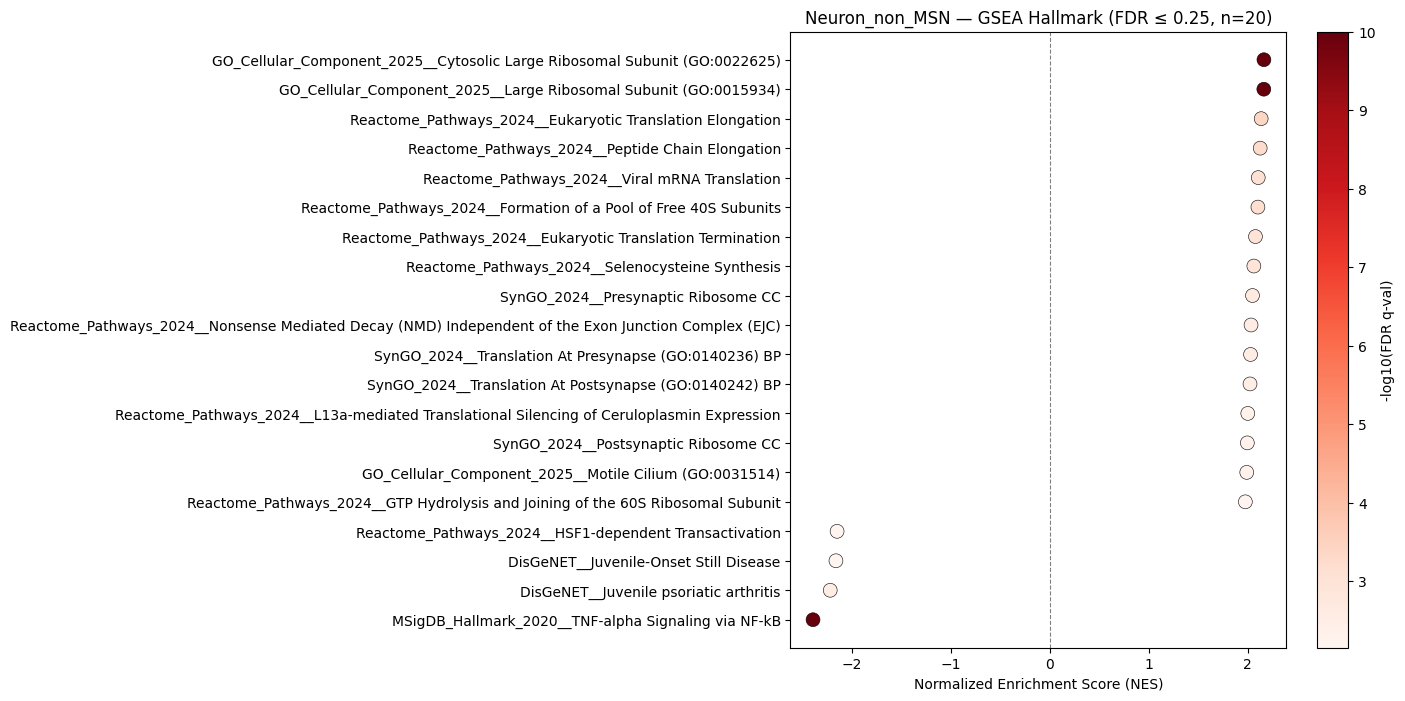

eMSN_D1D2


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,ENSG00000236948,0.869184,0.000175,False,0.015140
1,ENSG00000236266,0.770254,0.022204,False,0.004602
2,LOC105376805,0.601878,0.032078,False,NaN
3,GRIK3,0.939126,0.000543,False,-0.087813
4,ENSG00000248458,0.680682,0.048912,False,0.023302
...,...,...,...,...,...
216,LOC105377209,0.690037,0.021191,False,NaN
217,RPS4X,0.674431,0.007214,False,-0.031390
218,RPL36A,0.570636,0.011402,False,-0.061517
219,TMSB15C,0.768567,0.026203,False,0.015547


6


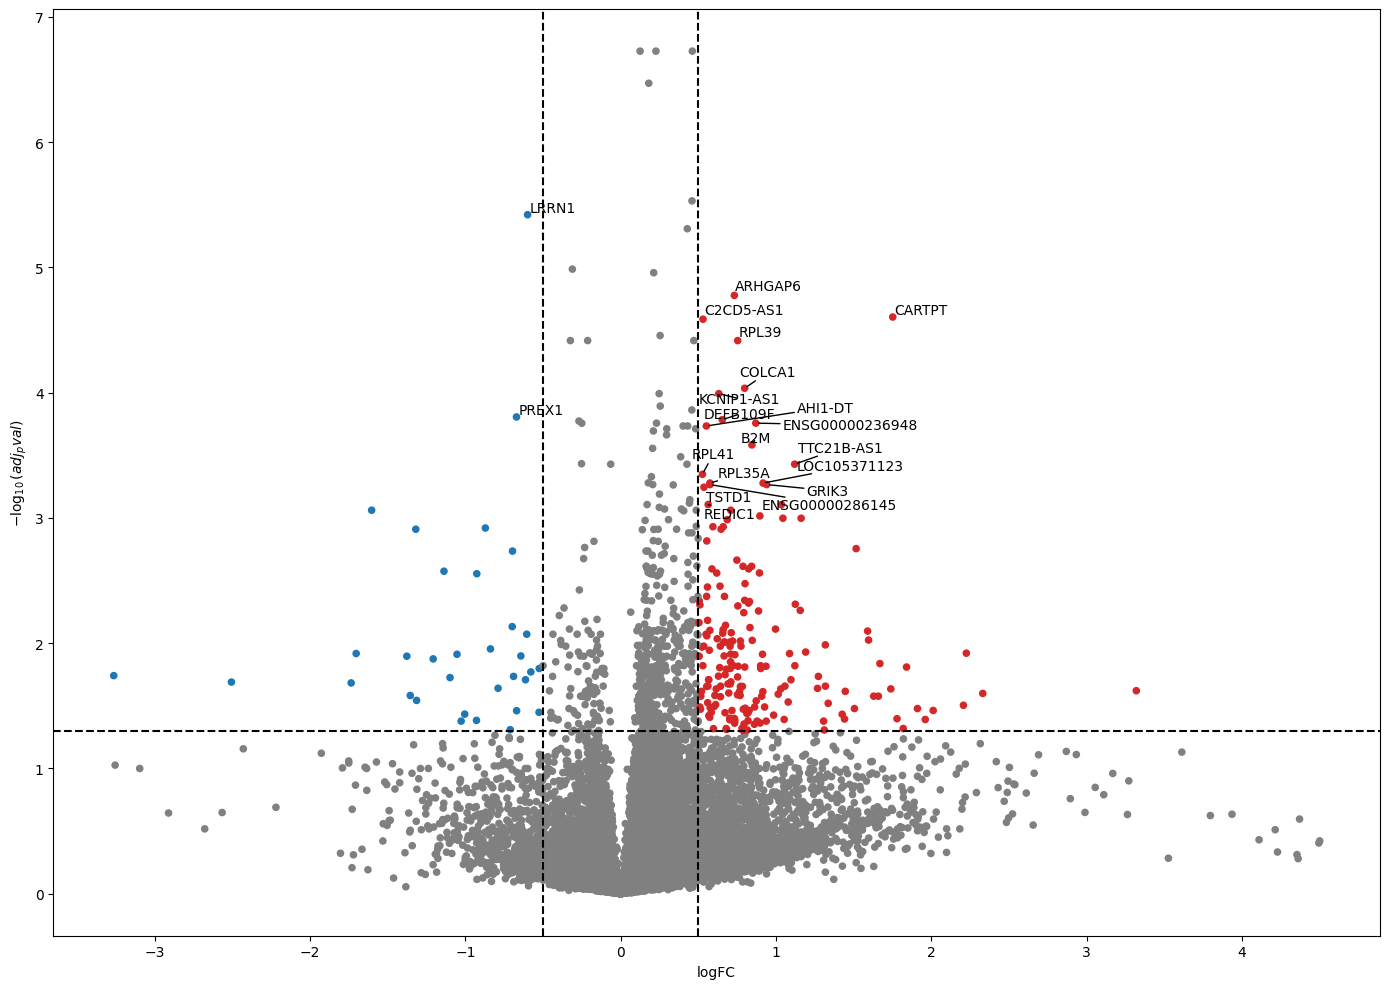

2026-02-21 15:09:25,931 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:09:25,972 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:09:25,974 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:09:26,248 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:09:26,417 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:09:26,419 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:09:26,429 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:09:26,964 [INFO] 5913 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:09:26,967 [INFO] 7347 gene_sets used for further statistical testing.....
2026-02-21 15:09:26,967 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:13:47,218 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 132


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
6,Reactome_Pathways_2024__Formation of a Pool of...,0.808758,2.414889,0.0,0.0,61/99
7,Reactome_Pathways_2024__Response of EIF2AK4 (G...,0.807444,2.394616,0.0,0.0,62/99
8,SynGO_2024__Postsynaptic Ribosome CC,0.830641,2.387386,0.0,0.0,50/69
23,Reactome_Pathways_2024__Nonsense-Mediated Deca...,0.749953,2.239388,0.0,0.0,60/113
14,Reactome_Pathways_2024__Selenoamino Acid Metab...,0.765813,2.306840,0.0,0.0,62/114
17,Reactome_Pathways_2024__Cellular Response to S...,0.741996,2.276087,0.0,0.0,67/148
15,Reactome_Pathways_2024__SARS-CoV-1 Modulates H...,0.847060,2.280306,0.0,0.0,25/36
16,GO_Cellular_Component_2025__Cytosolic Large Ri...,0.828201,2.277792,0.0,0.0,34/48
4,Reactome_Pathways_2024__Selenocysteine Synthesis,0.823391,2.433046,0.0,0.0,60/91
5,Reactome_Pathways_2024__Eukaryotic Translation...,0.822228,2.424828,0.0,0.0,60/90


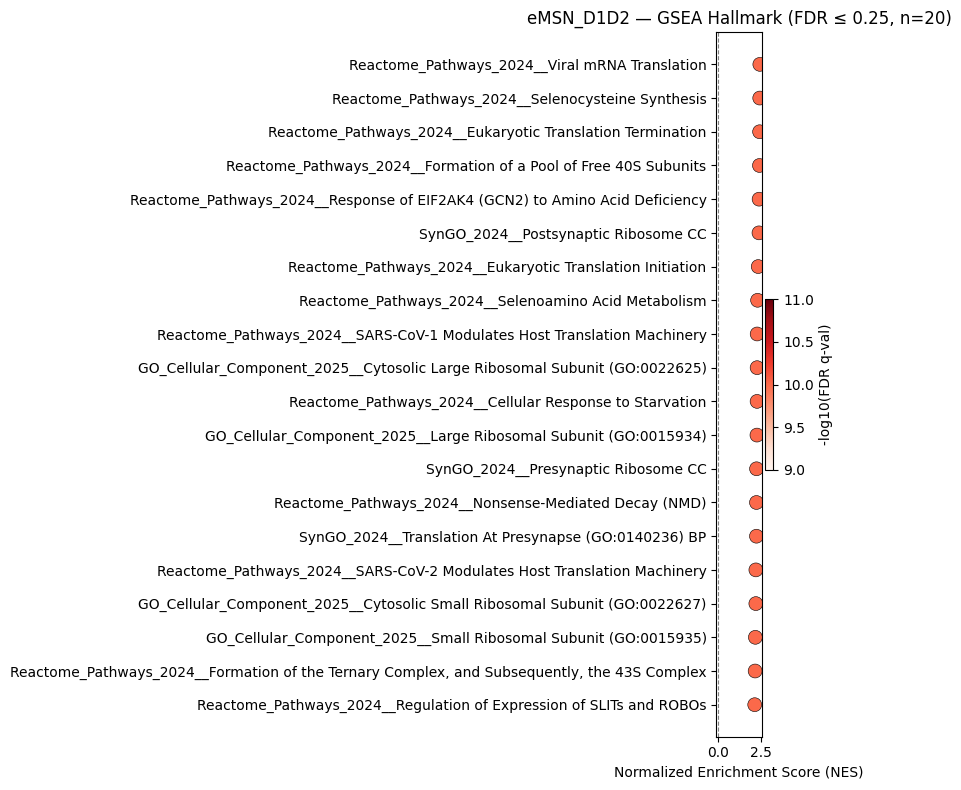

Matrix


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,PLEKHN1,-0.804434,0.020907,False,-0.028429
1,LINC01134,-0.805952,0.001679,False,-0.036615
2,IGSF21,1.191371,0.001892,False,0.026849
3,C1QC,0.976366,0.033708,False,-0.005536
4,GRHL3,0.553827,0.030919,False,0.019593
...,...,...,...,...,...
200,NHIP,1.118048,0.020093,False,0.000396
201,ENSG00000283546,1.147499,0.001801,False,0.014833
202,GK-AS1,0.608103,0.002291,False,-0.003153
203,ERCC6L,0.558121,0.032342,False,-0.002940


3


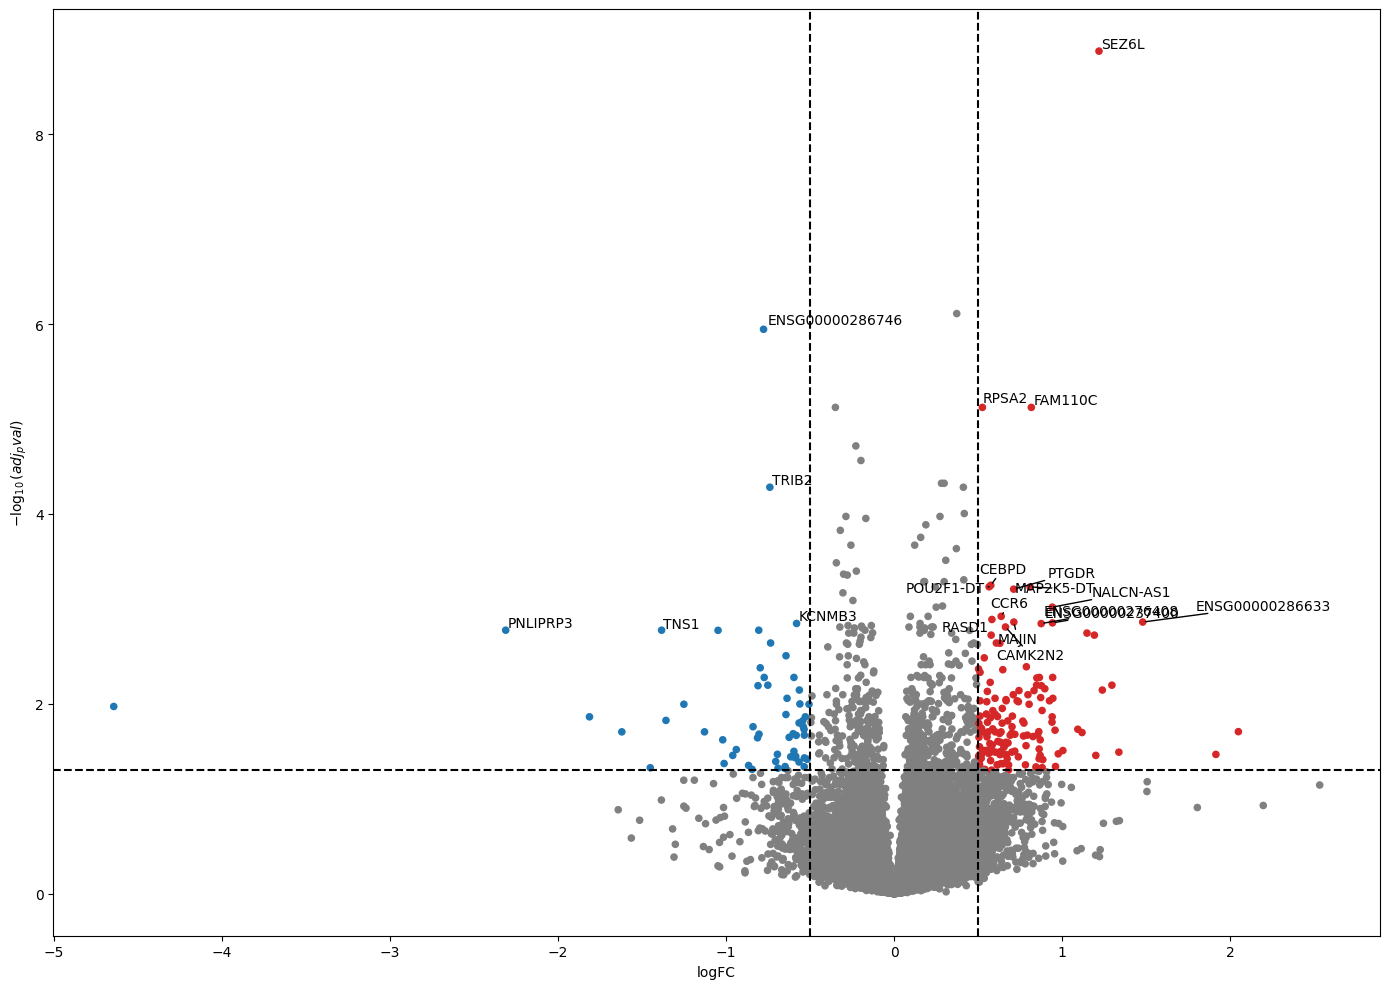

2026-02-21 15:13:52,840 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:13:52,883 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:13:52,886 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:13:53,167 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:13:55,262 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:13:55,265 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:13:55,275 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:13:55,847 [INFO] 5637 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:13:55,849 [INFO] 7623 gene_sets used for further statistical testing.....
2026-02-21 15:13:55,850 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:18:51,457 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 61


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
1,Reactome_Pathways_2024__O-glycosylation of TSR...,-0.668202,-2.208776,0.000000,0.004350,15/35
0,Reactome_Pathways_2024__Defective B3GALTL Caus...,-0.673864,-2.214710,0.000000,0.007250,15/34
2,DisGeNET__Ectopic kidney,-0.766207,-2.094181,0.000000,0.064280,6/16
3,DisGeNET__Skin tag,-0.825399,-2.074630,0.000000,0.069959,6/12
5,DisGeNET__Psychological symptom,-0.840246,-2.052053,0.000000,0.072738,3/12
7,Reactome_Pathways_2024__Phase 0 - Rapid Depola...,-0.637440,-2.029488,0.000000,0.075578,11/30
4,"DisGeNET__Depression, Postpartum",-0.789228,-2.057952,0.000000,0.076846,5/13
6,DisGeNET__Gastrointestinal Stromal Sarcoma,-0.581484,-2.033503,0.000000,0.080575,17/48
12,MSigDB_Hallmark_2020__Unfolded Protein Response,0.569855,1.955914,0.000000,0.086812,41/109
9,DisGeNET__Thick skin,-0.666364,-2.000916,0.003067,0.090766,8/26


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


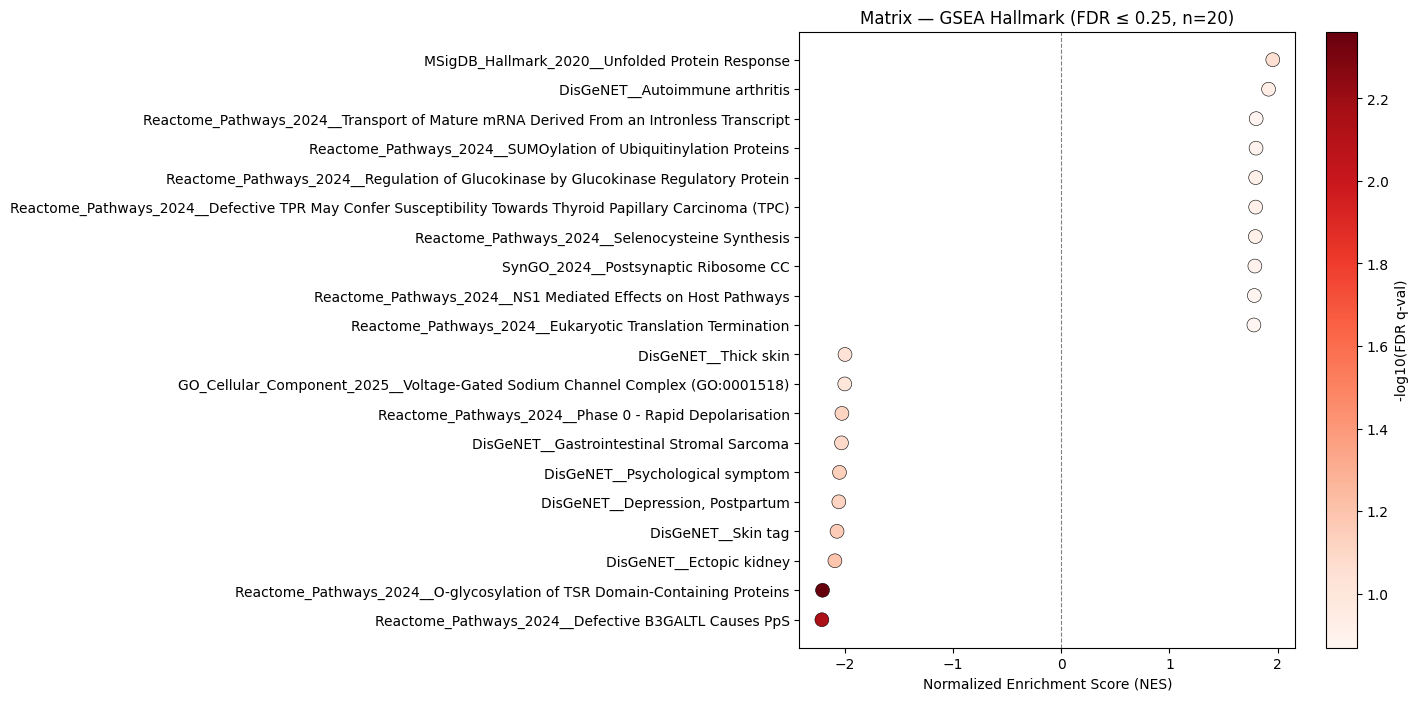

Patch


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,ENSG00000272426,0.745979,1.833642e-02,False,0.015764
1,WNT4,-0.614188,2.447601e-02,False,0.039701
2,CRYBG2,0.897278,3.001676e-02,False,-0.006393
3,MFSD2A,0.718914,6.861610e-07,False,0.096371
4,MPL,0.641191,3.726127e-02,False,0.007192
...,...,...,...,...,...
150,AR,-0.633262,2.438307e-02,False,-0.007892
151,ERCC6L,0.745137,3.880885e-02,False,-0.002940
152,CITED1,1.844094,2.919714e-02,False,0.004505
153,COL4A6,1.434443,1.318779e-03,False,0.014113


8


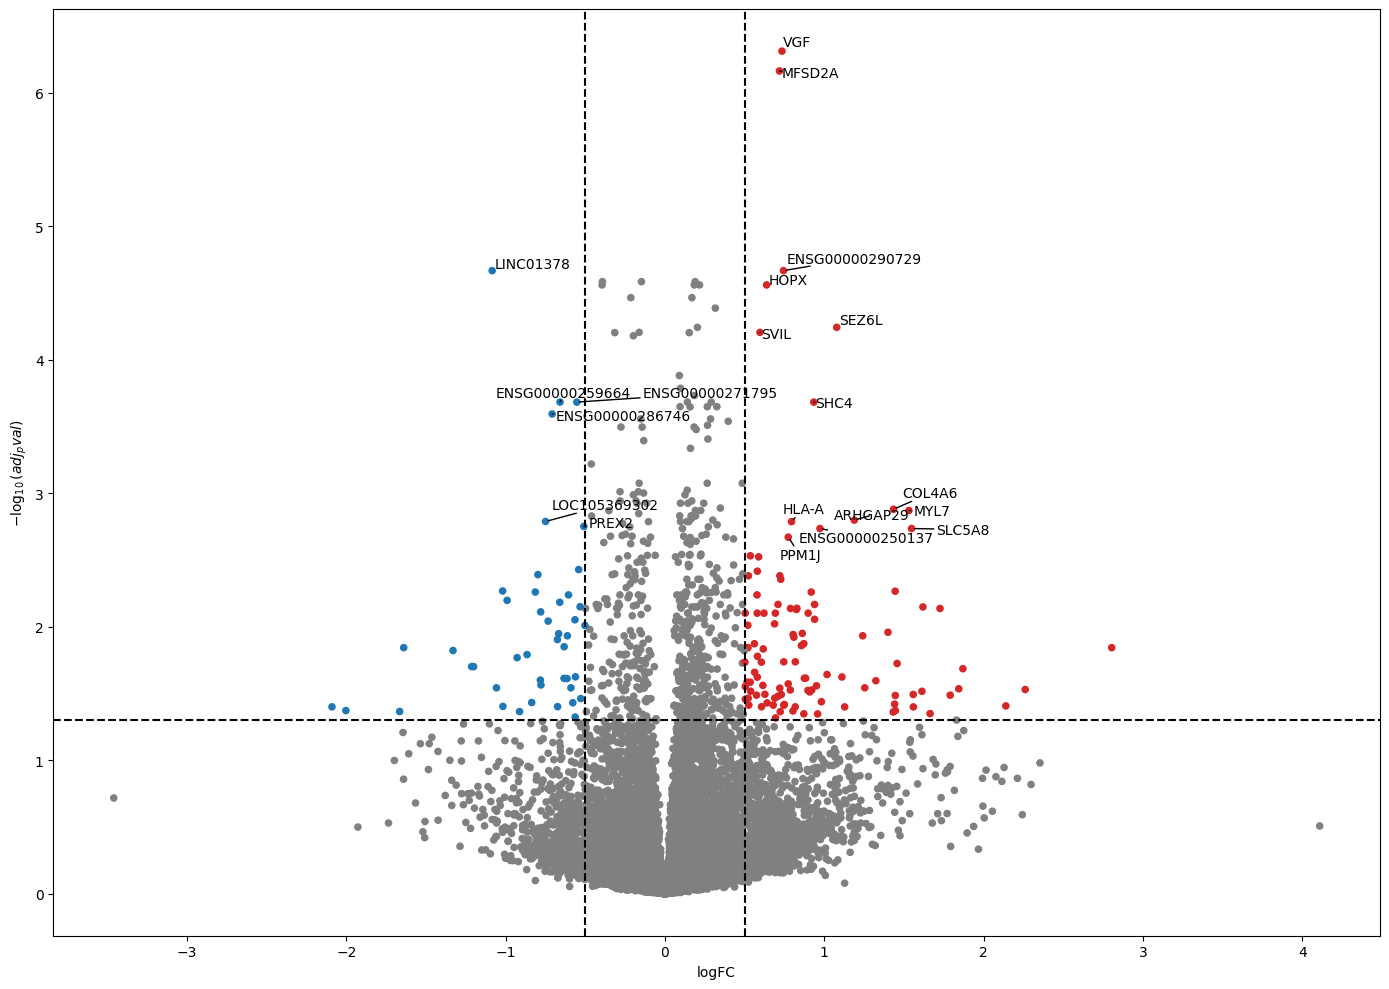

2026-02-21 15:18:56,767 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:18:56,811 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:18:56,814 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:18:57,095 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:18:57,264 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:18:57,266 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:18:57,287 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:18:57,852 [INFO] 5603 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:18:57,854 [INFO] 7657 gene_sets used for further statistical testing.....
2026-02-21 15:18:57,855 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:23:56,982 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 85


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
31,"DisGeNET__Thrombotic Infarction, Middle Cerebr...",0.693044,1.786460,0.001520,0.106211,8/24
32,DisGeNET__Middle Cerebral Artery Embolus,0.693044,1.786460,0.001520,0.106211,8/24
30,DisGeNET__Middle Cerebral Artery Syndrome,0.693044,1.786460,0.001520,0.106211,8/24
33,DisGeNET__Right Middle Cerebral Artery Infarction,0.693044,1.786460,0.001520,0.106211,8/24
36,"DisGeNET__Embolic Infarction, Middle Cerebral ...",0.693044,1.786460,0.001520,0.106211,8/24
35,DisGeNET__Left Middle Cerebral Artery Infarction,0.693044,1.786460,0.001520,0.106211,8/24
34,DisGeNET__Middle Cerebral Artery Thrombosis,0.693044,1.786460,0.001520,0.106211,8/24
41,DisGeNET__Bare Lymphocyte Syndrome,0.721258,1.782898,0.001497,0.110494,6/19
5,Reactome_Pathways_2024__Synthesis of Active Ub...,0.702750,1.879767,0.000000,0.112359,13/29
25,Reactome_Pathways_2024__GTP Hydrolysis and Joi...,0.543194,1.801718,0.000000,0.122384,47/111


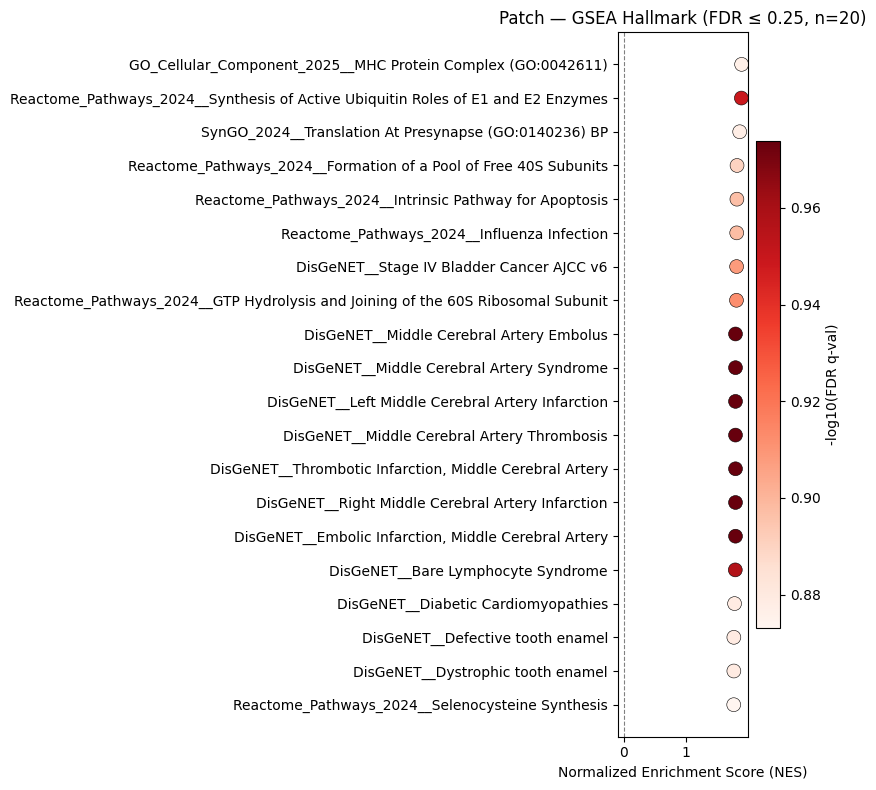

eMSN_StrioMat


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,HES4,0.584171,0.006194,False,0.061483
1,TSSK3,0.919350,0.015113,False,0.028814
2,DYNLT5,0.856675,0.016327,False,-0.011668
3,ENSG00000228560,2.162585,0.035452,False,0.058029
4,RPS7,0.507283,0.035452,False,-0.020818
5,ENSG00000223884,0.922444,0.026069,False,0.013832
6,CD302,0.686498,0.039014,False,-0.129057
7,ENSG00000272807,0.764795,0.036624,False,-0.000596
8,RPL32,0.826352,0.005424,False,-0.028049
9,HTR1F,10.867010,0.006194,False,0.014165


2


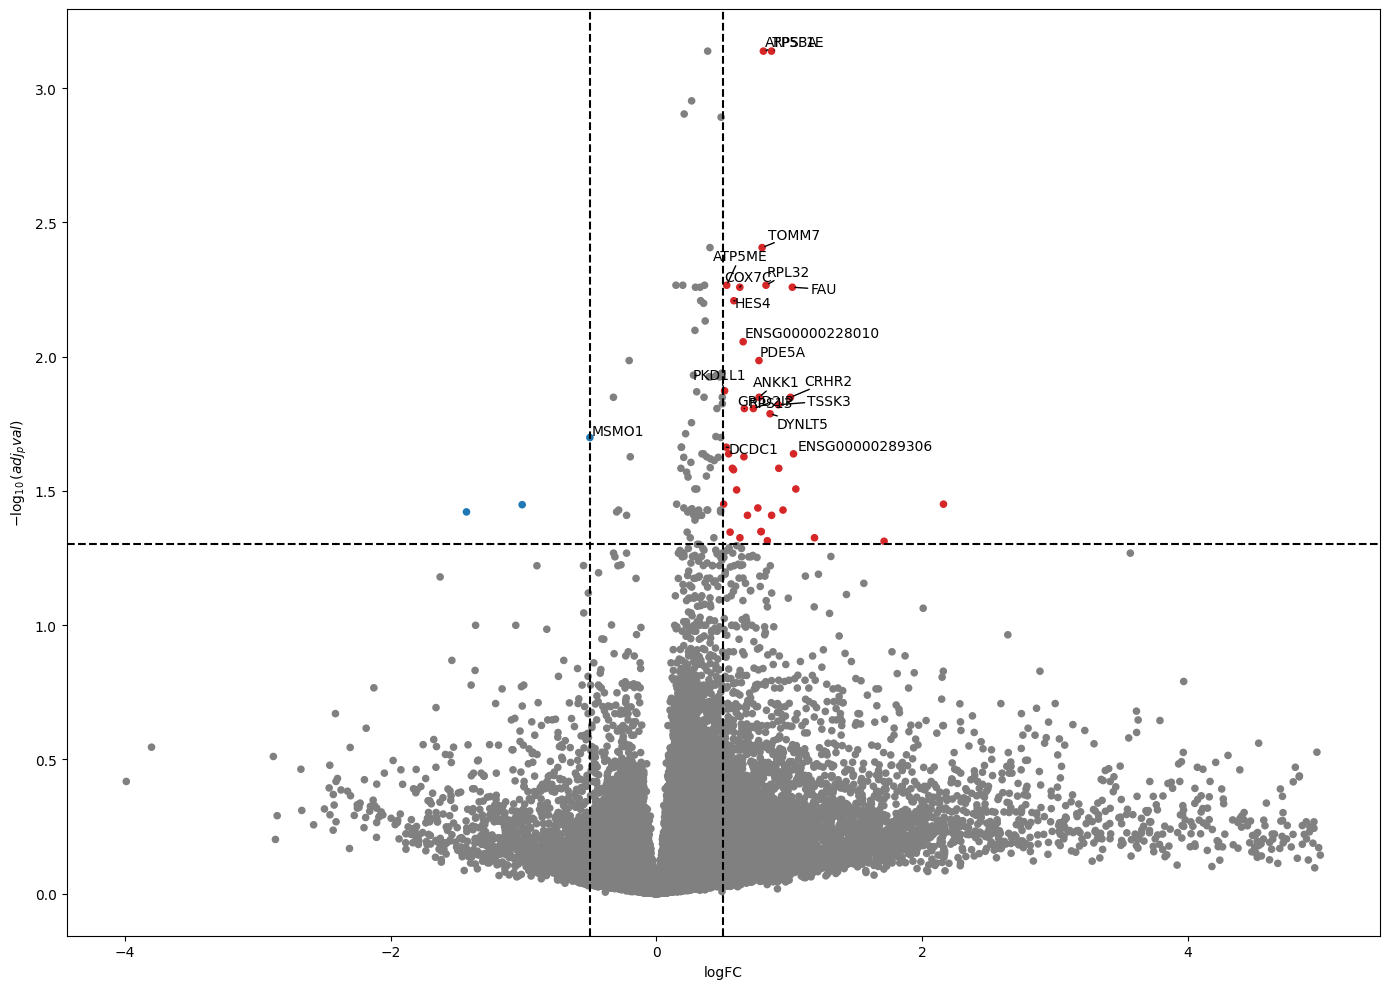

2026-02-21 15:24:02,522 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:24:02,563 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:24:02,565 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:24:02,832 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:24:03,006 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:24:03,009 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:24:03,019 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:24:03,567 [INFO] 5705 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:24:03,569 [INFO] 7555 gene_sets used for further statistical testing.....
2026-02-21 15:24:03,569 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:28:47,854 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 94


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
0,Reactome_Pathways_2024__Eukaryotic Translation...,0.850649,2.500442,0.0,0.0,65/91
1,Reactome_Pathways_2024__Peptide Chain Elongation,0.852162,2.495978,0.0,0.0,64/87
40,Reactome_Pathways_2024__Signaling by ROBO Rece...,0.692575,2.115948,0.0,0.0,87/195
39,Reactome_Pathways_2024__rRNA Processing,0.696456,2.124320,0.0,0.0,83/209
38,Reactome_Pathways_2024__Translation Initiation...,0.752497,2.130406,0.0,0.0,25/58
21,GO_Cellular_Component_2025__Cytosolic Large Ri...,0.836894,2.315133,0.0,0.0,37/48
20,GO_Cellular_Component_2025__Large Ribosomal Su...,0.838349,2.320341,0.0,0.0,38/49
2,Reactome_Pathways_2024__Viral mRNA Translation,0.845375,2.482225,0.0,0.0,63/87
42,DisGeNET__Pallor,0.755809,2.069632,0.0,0.0,24/43
41,Reactome_Pathways_2024__SARS-CoV-1-host Intera...,0.719237,2.102625,0.0,0.0,33/88


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


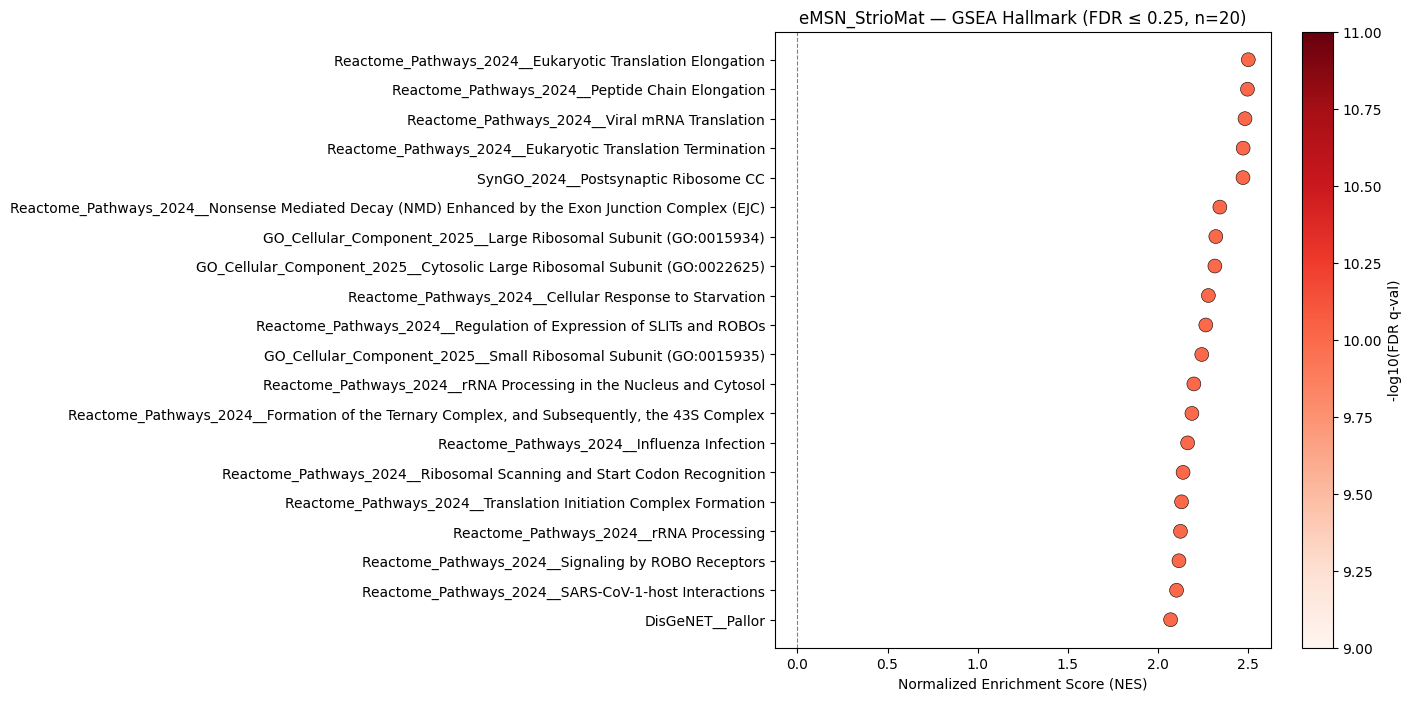

eMSN_NUDAP


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,SLC35F3,-0.622969,0.038492,False,-0.094320
1,HIBCH,0.533924,0.011169,False,0.042206
2,UBE2E1,0.918685,0.022936,False,-0.014570
3,PCNP,0.503212,0.038492,False,0.078188
4,HDAC9,0.680556,0.006674,False,0.082212
5,TRDMT1,0.545513,0.006674,False,-0.095367
6,LINC02653,10.774320,0.031459,False,0.006533
7,CCS,1.216343,0.021593,False,0.078633
8,PTPRQ,1.786152,0.038492,True,0.153302
9,ITGA11,8.899834,0.039235,False,-0.027407


2


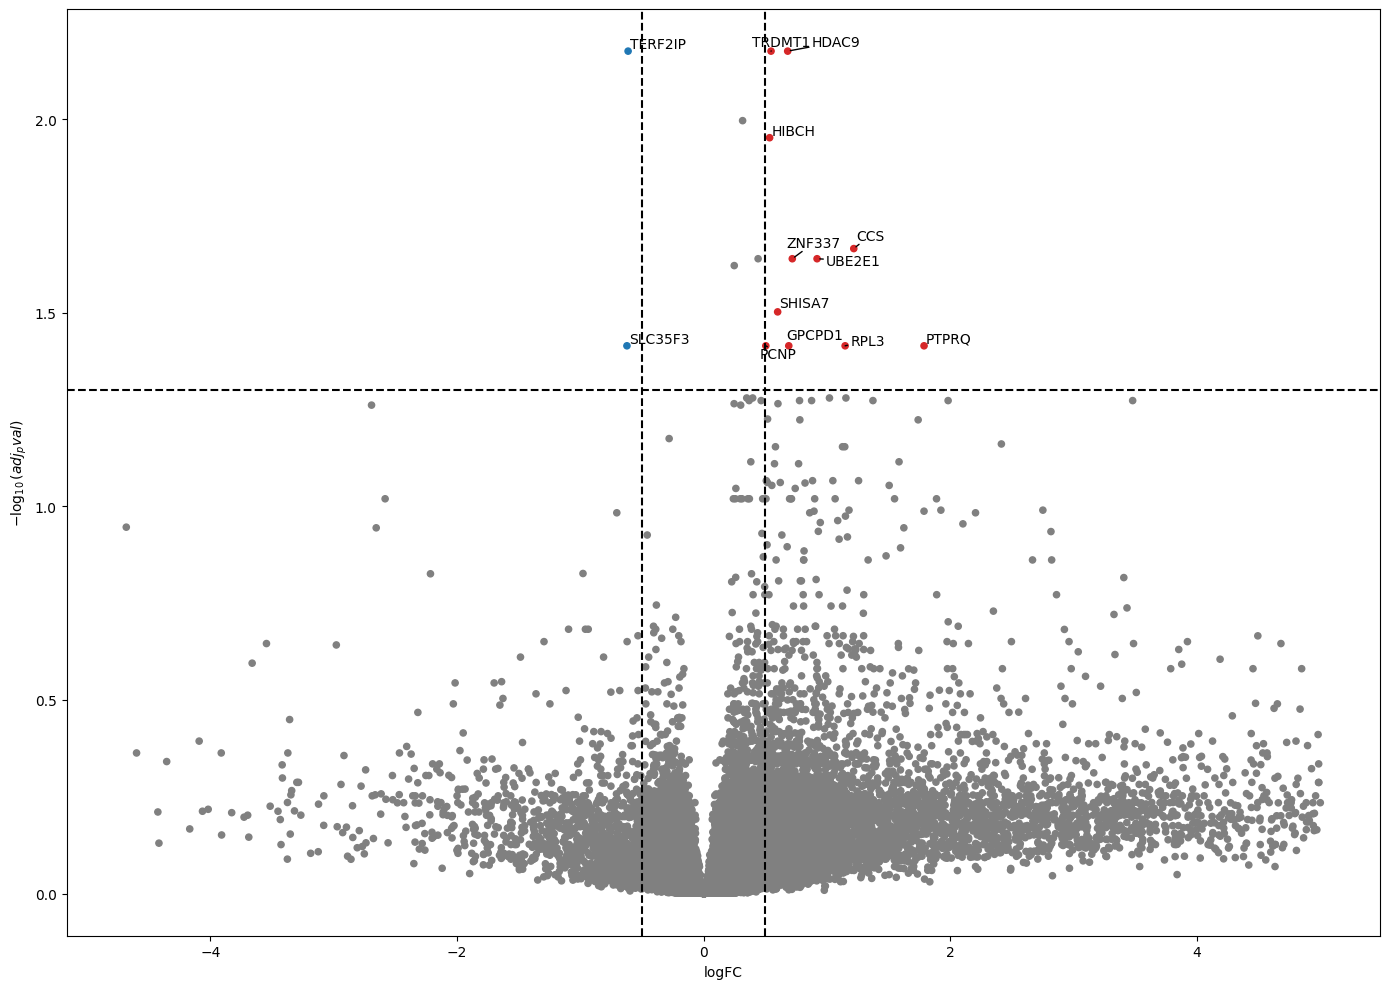

2026-02-21 15:28:54,308 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:28:54,342 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:28:54,344 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:28:54,622 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:28:54,794 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:28:54,796 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:28:54,807 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:28:55,345 [INFO] 6214 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:28:55,347 [INFO] 7046 gene_sets used for further statistical testing.....
2026-02-21 15:28:55,348 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:32:32,116 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 59


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
18,Reactome_Pathways_2024__SRP-dependent Cotransl...,0.621483,1.854336,0.0,0.026092,54/110
19,Reactome_Pathways_2024__SARS-CoV-1 Modulates H...,0.691985,1.847947,0.0,0.027362,23/36
17,Reactome_Pathways_2024__Eukaryotic Translation...,0.627154,1.856048,0.0,0.028583,44/90
16,Reactome_Pathways_2024__Formation of a Pool of...,0.625816,1.858493,0.0,0.030782,46/99
29,Reactome_Pathways_2024__Selenocysteine Synthesis,0.612373,1.810334,0.0,0.032197,45/91
30,SynGO_2024__Presynaptic Ribosome CC,0.642725,1.807770,0.0,0.032225,28/51
28,Reactome_Pathways_2024__Formation of the Terna...,0.650662,1.811723,0.0,0.033547,23/51
27,DisGeNET__Neck muscle weakness,0.769531,1.812783,0.0,0.034822,7/17
15,Reactome_Pathways_2024__Eukaryotic Translation...,0.628232,1.860446,0.0,0.035014,45/91
26,Reactome_Pathways_2024__L13a-mediated Translat...,0.607384,1.815443,0.0,0.035248,47/109


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


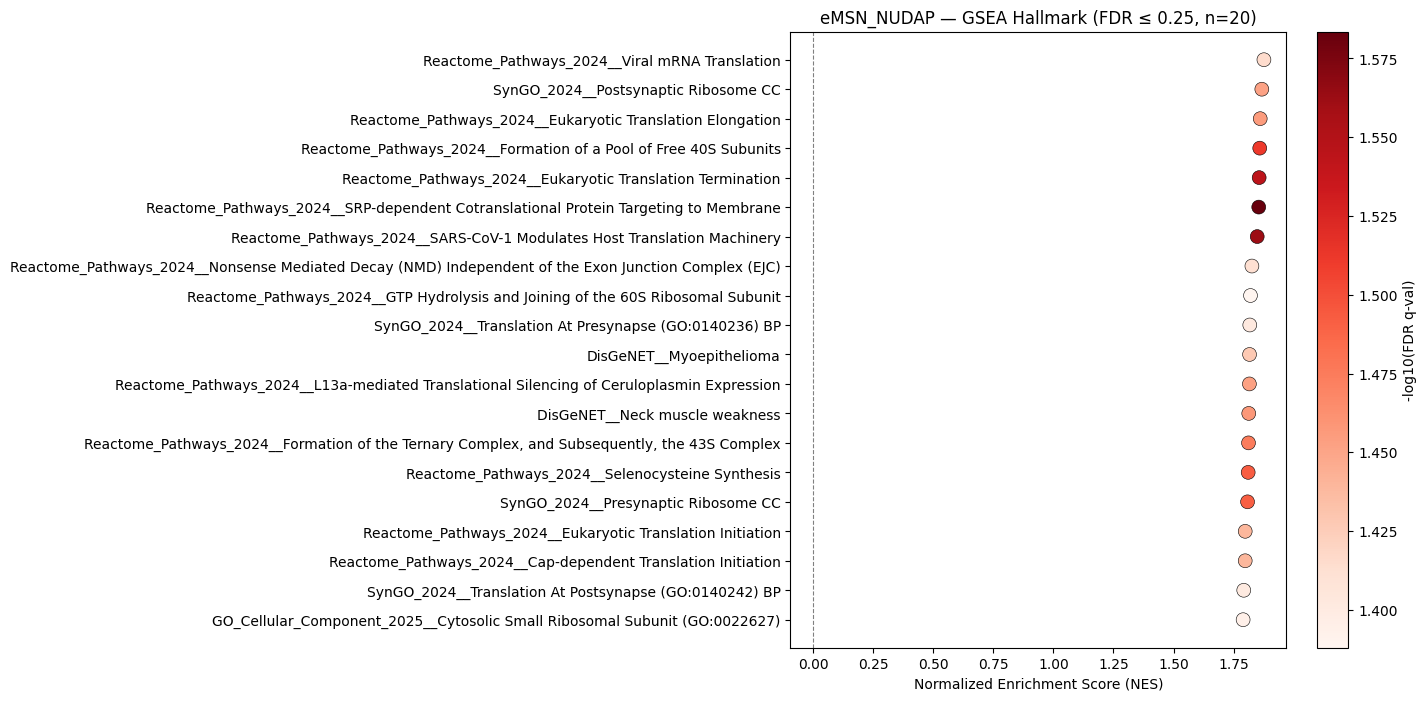

Oligodendrocyte


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,TMEM54,0.772575,0.000250,False,0.034773
1,GBP1,1.109603,0.048179,False,-0.000590
2,H2AC20,0.501331,0.026381,False,-0.006143
3,S100A16,0.678009,0.002729,False,0.003022
4,TAGLN2,0.697675,0.004815,False,0.002240
...,...,...,...,...,...
104,SAMHD1,0.731254,0.004916,False,-0.021374
105,SELENOM,0.627703,0.021160,False,0.056634
106,MIR3667HG,0.712128,0.032029,False,-0.013238
107,PRKX,0.725351,0.001037,False,-0.007326


1


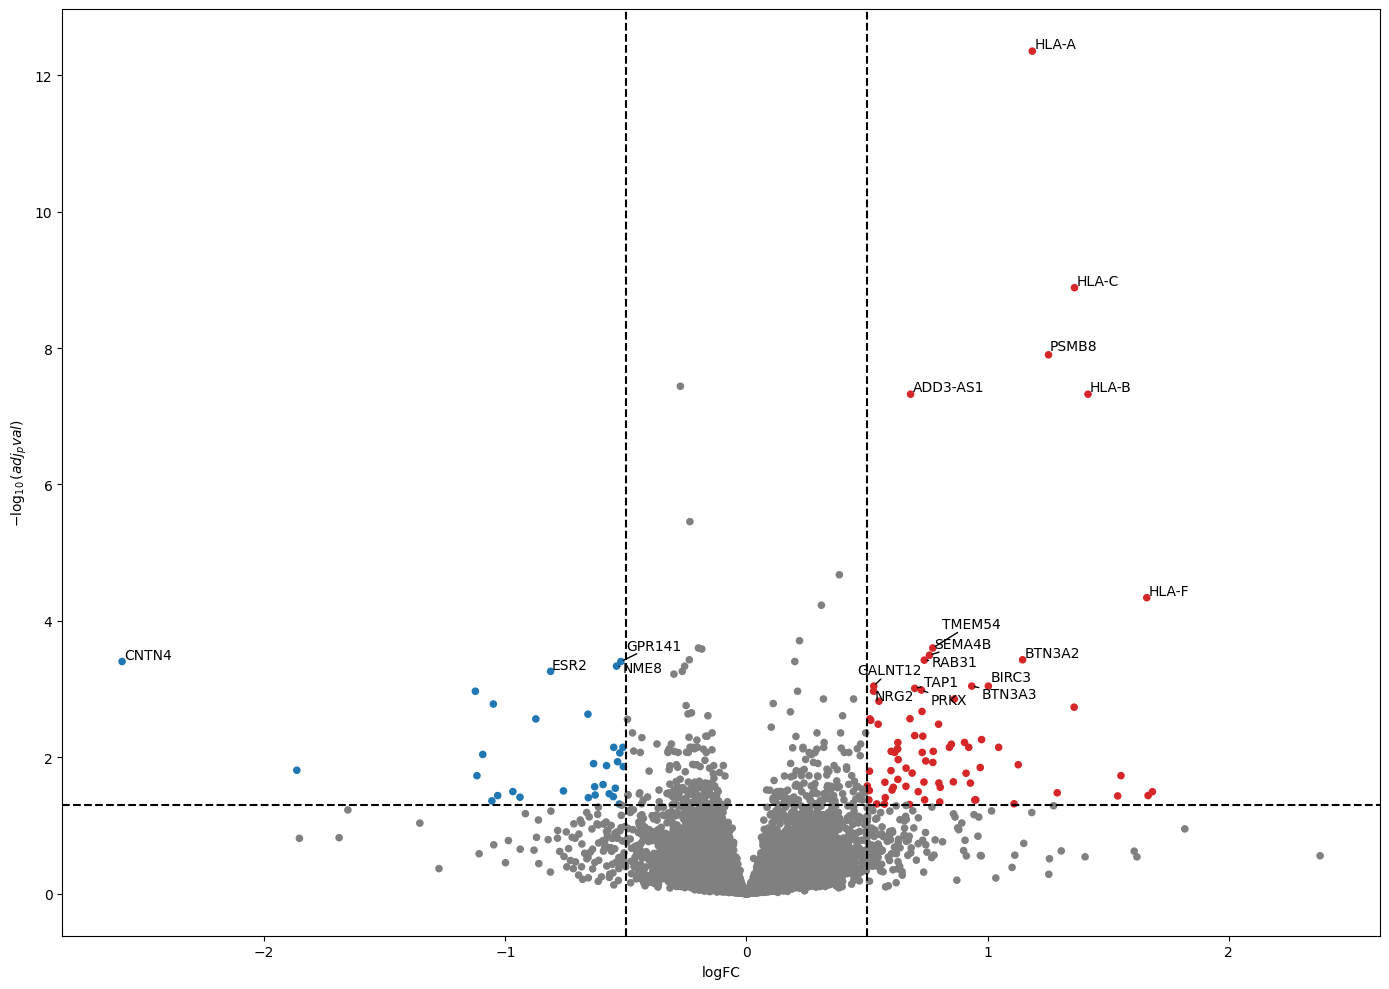

2026-02-21 15:32:36,266 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:32:36,293 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:32:36,295 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:32:36,574 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:32:36,748 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:32:36,751 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:32:36,761 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:32:37,255 [INFO] 6889 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:32:37,257 [INFO] 6371 gene_sets used for further statistical testing.....
2026-02-21 15:32:37,257 [INFO] Start to run GSEA...Might take a while..................
2026-02-21 15:35:15,747 [INFO] Congratulations. GSEApy runs successfully................




  GSEA significant pathways (FDR ≤ 0.25): 1208


,Term,ES,NES,NOM p-val,FDR q-val,Tag %
0,Reactome_Pathways_2024__Eukaryotic Translation...,0.716841,2.554816,0.0,0.0,55/89
31,GO_Cellular_Component_2025__Phagocytic Vesicle...,0.689867,2.309818,0.0,0.0,11/63
30,Reactome_Pathways_2024__ER-Phagosome Pathway,0.693382,2.311804,0.0,0.0,20/66
29,Reactome_Pathways_2024__Regulation of Expressi...,0.615891,2.319248,0.0,0.0,70/147
28,MSigDB_Hallmark_2020__Oxidative Phosphorylation,0.584979,2.324920,0.0,0.0,82/196
27,Reactome_Pathways_2024__Antigen processing-Cro...,0.688896,2.325717,0.0,0.0,21/70
26,Reactome_Pathways_2024__Selenoamino Acid Metab...,0.640124,2.332013,0.0,0.0,54/110
25,Reactome_Pathways_2024__Cap-dependent Translat...,0.627184,2.339738,0.0,0.0,57/115
24,Reactome_Pathways_2024__Eukaryotic Translation...,0.627184,2.339738,0.0,0.0,57/115
23,"DisGeNET__HEMOCHROMATOSIS, TYPE 1",0.799581,2.341126,0.0,0.0,10/33


/tmp/ipykernel_1700881/1187267743.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


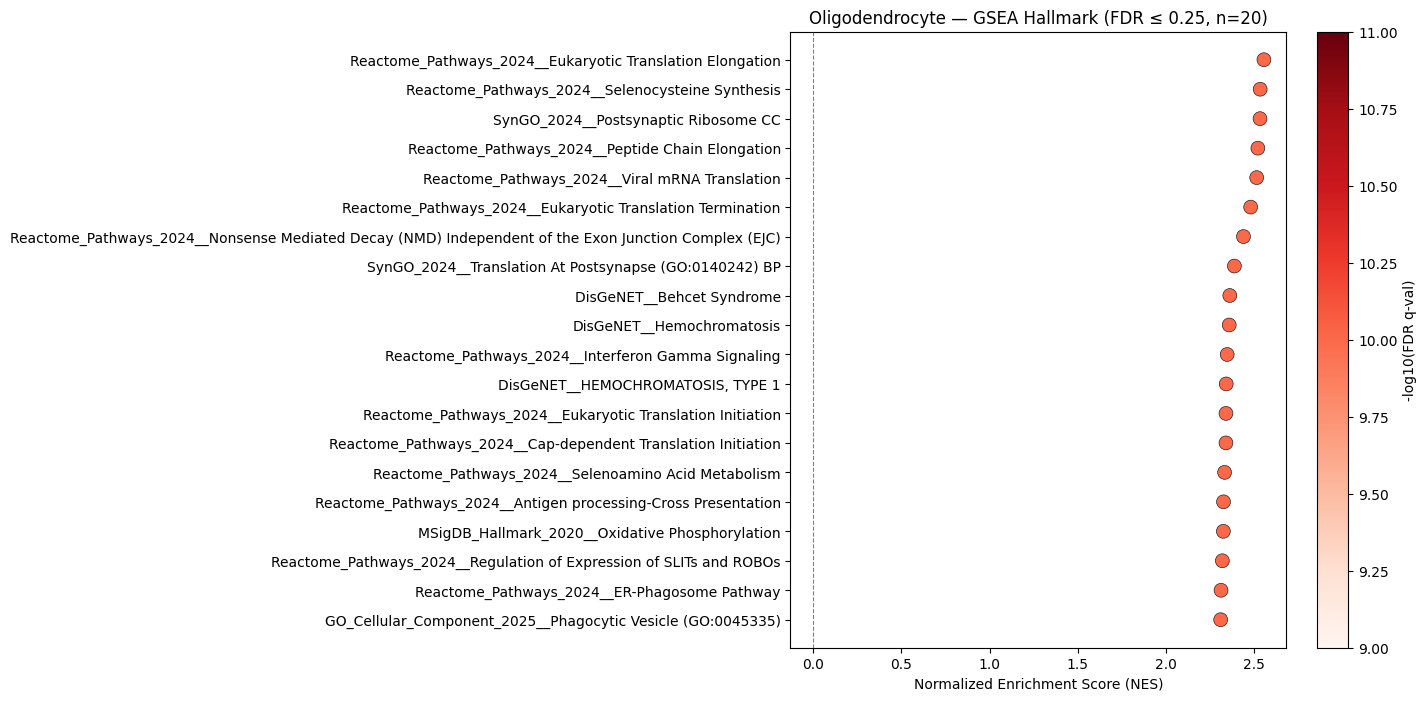

OPC


,gene,logFC_conditionXDP,adj_p_conditionXDP,is_grad_gene,mean_spearman
0,TMEM51-AS1,-0.501103,0.006042,False,-0.005226
1,ENSG00000237480,2.440328,0.000001,False,-0.005629
2,ITGA10,-0.804221,0.045154,False,-0.021398
3,H2AC20,0.507321,0.042386,False,-0.006143
4,PCP4L1,-0.835290,0.010769,False,-0.010323
...,...,...,...,...,...
64,DACH2,0.904849,0.016055,False,0.052550
65,CHRDL1,0.768967,0.044556,False,-0.037997
66,ATP2B3,-0.880688,0.002155,False,-0.017610
67,DUSP9,0.813357,0.021436,False,0.023113


4


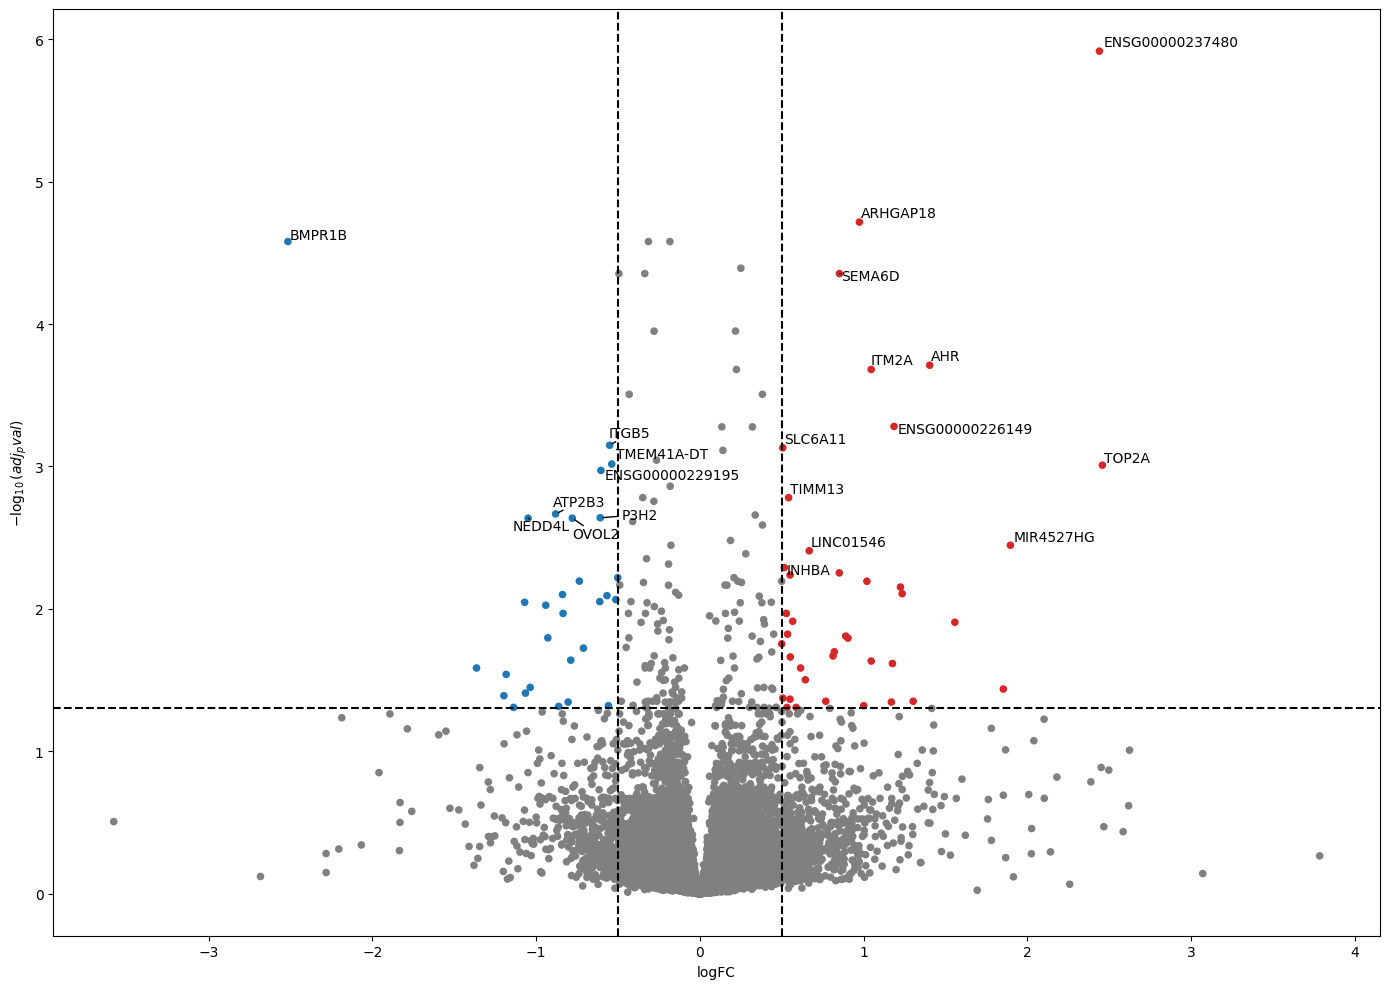

2026-02-21 15:35:19,565 [INFO] Parsing data files for GSEA.............................
2026-02-21 15:35:19,598 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:35:19,601 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file


['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024', 'DSigDB', 'Data_Acquisition_Method_Most_Popular_Genes', 'DepMap_CRISPR_GeneDependency

2026-02-21 15:35:19,895 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:35:20,068 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:35:20,070 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:35:20,079 [INFO] Enrichr library gene sets already downloaded in: /home/gdallagl/.cache/gseapy, use local file
2026-02-21 15:35:20,613 [INFO] 6235 gene_sets have been filtered out when max_size=500 and min_size=10
2026-02-21 15:35:20,614 [INFO] 7025 gene_sets used for further statistical testing.....
2026-02-21 15:35:20,615 [INFO] Start to run GSEA...Might take a while..................


KeyboardInterrupt: 

In [9]:
PVAL_COL=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL="gene"
PVAL_THR=0.05
LOGFC_THR=0.5
GRAD_THR=0.1
from statsmodels.stats.multitest import multipletests


for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique().tolist():

    #ct="eMSN_NUDAP"
    if "-" in ct:
        continue
    print(ct)

    ADATA_PATH_QS = f"{os.path.dirname(ADATA_PATH)}/{ct}/{os.path.splitext(os.path.basename(ADATA_PATH))[0]}.qs"
    SAVE_HEALTHY_PCA_RESULT = os.path.dirname(ADATA_PATH_QS)
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv"

    df_nebula = pd.read_csv(save_csv_path)
    #display(df_nebula)
    # print(df_nebula[PVAL_COL].isna().sum())
    # print(df_nebula[LOGFC_COL].isna().sum())

    col_p_adj = f"adj_{PVAL_COL}"
    df_nebula = df_nebula.dropna(subset=[PVAL_COL, LOGFC_COL])
    df_nebula[col_p_adj] = multipletests(df_nebula[PVAL_COL],method="fdr_bh")[1]

    df_sig = df_nebula[(np.abs(df_nebula[LOGFC_COL]) >= LOGFC_THR) & (df_nebula[col_p_adj] <= PVAL_THR)]
    df_sig = df_sig.merge(df_grad, how="left", on="gene")
    df_sig["is_grad_gene"] = df_sig["mean_spearman"] >= GRAD_THR
    display(df_sig[[GENE_COL, LOGFC_COL, col_p_adj, "is_grad_gene", "mean_spearman"]])
    print(df_sig["is_grad_gene"].sum())

    # DEG.plot_vulcano(
    #     df_nebula,
    #     logfc_col=LOGFC_COL, 
    #     pval_col=col_p_adj, 
    #     gene_col=GENE_COL, 
    #     categories=None, 
    #     pval_thresh=PVAL_THR, 
    #     logfc_thresh=LOGFC_THR,
    #     to_label=10, 
    #     figsize=(10, 8), 
    #     max_y=None
    # )

    import decoupler as dc

    df_plot = df_nebula.rename(columns={
        LOGFC_COL: "logFC",
        col_p_adj: "adj_pval"
    })

    dc.pl.volcano(
        df_plot.set_index(GENE_COL),
        x="logFC",
        y="adj_pval",
        top=20,
        thr_stat=LOGFC_THR,
        thr_sign=PVAL_THR,
        figsize=(14, 10),
        max_stat=5,        # clip x-axis to ±5
    )
    plt.show()





    # ------------------------------------------------------------------ #
    #  Simple pre-ranked GSEA                                             #
    # ------------------------------------------------------------------ #
    import gseapy as gp
    print(gp.get_library_name())

    # Rank metric: sign(logFC) * -log10(p_raw)  — keeps direction & magnitude
    # RAW p-values (not adjusted)-->GSEA does its own permutation-based multiple testing
    df_rank = df_nebula.copy()
    df_rank["rank_metric"] = (
        np.sign(df_rank[LOGFC_COL]) *
        -np.log10(df_rank[PVAL_COL].clip(lower=1e-300))
    )

    # Drop duplicates (keep highest |rank|) and sort descending
    df_rank = (
        df_rank
        .sort_values("rank_metric", ascending=False)
        .drop_duplicates(subset=[GENE_COL]) # rmeove dupicated genes
    )
    ranked_series = df_rank.set_index(GENE_COL)["rank_metric"]

    # GSEA FDR is not BH-adjusted p-values
    # emptircal and more comservative, thus need more lenint thr
    THR_FDR_GSEA=0.25

    try:
        # ES --> enriuchemnt score
        # NES -->romalised ES --> by gene set size
        # ignificance is assessed by randomly permuting the gene order --> creating nulld sitruvtion
        gsea_res = gp.prerank(
            rnk=ranked_series,
            gene_sets=
                ["MSigDB_Hallmark_2020", "JASPAR_PWM_Human_2025", "DisGeNET", "SynGO_2024", #GO_Biological_Process_2025, KEGG_2026
                "GO_Cellular_Component_2025", "Reactome_Pathways_2024"],
            seed=42,
            permutation_num=1000,
            min_size=10, #if fewer than 10 genes in the set are present in your data, skip it.
            max_size=500, #if more than 500 genes in the set overlap your data, skip it
            verbose=True,
        )

        # Cast to float to avoid the "no callable log10" error
        df_gsea = gsea_res.res2d.copy()
        for col in ["ES", "NES", "NOM p-val", "FDR q-val"]:
            df_gsea[col] = pd.to_numeric(df_gsea[col], errors="coerce")
        df_gsea = df_gsea.sort_values("FDR q-val")

        df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA]   # standard GSEA FDR cut-off

        print(f"\n  GSEA significant pathways (FDR ≤ {THR_FDR_GSEA}): {len(df_gsea_sig)}")
        display(
            df_gsea_sig[["Term", "ES", "NES", "NOM p-val", "FDR q-val", "Tag %"]]
            .head(20)
        )

        # Dot-plot of top 20 pathways by NES
        # x = NES (direction: positive = upregulated pathway)
        # color = -log10(FDR) (intensity = confidence)
        if len(df_gsea_sig) > 0:
            df_top = (
                df_gsea_sig
                .assign(
                    neg_log10_fdr=lambda d: -np.log10(
                        d["FDR q-val"].astype(float).clip(lower=1e-10)
                    )
                )
                .nlargest(20, "neg_log10_fdr")
                .sort_values("NES")
            )
            fig, ax = plt.subplots(figsize=(8, max(4, len(df_top) * 0.4)))
            sc = ax.scatter(
                df_top["NES"],
                df_top["Term"],
                c=df_top["neg_log10_fdr"],
                cmap="Reds",
                s=100,
                edgecolors="k",
                linewidths=0.4,
            )
            plt.colorbar(sc, ax=ax, label="-log10(FDR q-val)")
            ax.axvline(0, color="grey", lw=0.8, linestyle="--")
            ax.set_xlabel("Normalized Enrichment Score (NES)")
            ax.set_title(f"{ct} — GSEA Hallmark (FDR ≤ 0.25, n={len(df_top)})")
            plt.tight_layout()
            plt.show()
        else:
            print(f"  No significant pathways for {ct} at FDR ≤ 0.25")

    except Exception as e:
        print(f"  GSEA failed for {ct}: {e}")

    #break